In [57]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from mord import OrdinalRidge  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch 

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
import LeafletFA_utilities
importlib.reload(LeafletFA_utilities)

# Import functions from utilities.py 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
from LeafletFA_utilities import *

# check if using cuda device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Torch Version: 2.4.1.post300
CUDA Version: 12.0
cuda


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import glob
import os
import lzma
import pickle

In [59]:
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/ATSEfiles/TMS_atse_file_unanno_also_2025-03-03_15-00-44.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
db = gffutils.FeatureDB("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/ATSEfiles/vM27", keep_order=True)

### Identify best model fit

In [60]:
model_outputs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/leafletFAmodel/2025-03-03/"

# Check the specific pattern
run_summary_files = glob.glob(os.path.join(model_outputs, "*", "*run_summary.csv"))

# Read in the run summary files
run_summary = pd.concat([pd.read_csv(f) for f in run_summary_files])
print(run_summary.sort_values(by="best_elbo", ascending=True))

best_run = run_summary.sort_values(by="best_elbo", ascending=True).iloc[0]
print(f"The best run is {best_run['param_id']} with an ELBO of {best_run['best_elbo']}")

# Define paths
# run outputs is model_outputs followed by dir "run_param_id[0]"

run_outputs = os.path.join(model_outputs, f"run_{best_run['param_id']}")
model_file = os.path.join(run_outputs, "leafletfa_model.pkl.xz")

# Load the model
def load_model(model_file):
    with lzma.open(model_file, "rb") as f:
        model = pickle.load(f)
    print(f"Model loaded successfully from {model_file}")
    return model

# Load and store the model
leaflet_model = load_model(model_file)

   param_id    K  junc_specific_prior  waypoints_use     best_elbo  \
0         1   30                 True           True  3.935418e+06   
0        25   30                 True           True  3.936453e+06   
0         2   30                 True           True  3.954836e+06   
0        26   30                 True           True  3.965942e+06   
0         4   30                 True          False  3.969524e+06   
0        16   30                False          False  3.973844e+06   
0        17   30                False          False  3.974214e+06   
0        13   30                False           True  3.974979e+06   
0        41   30                False          False  3.981270e+06   
0        40   30                False          False  3.981311e+06   
0        14   30                False           True  3.984300e+06   
0         0   30                 True           True  3.984682e+06   
0         3   30                 True          False  3.985821e+06   
0        37   30    

In [61]:
### Load the original anndata object 
ATSE_anndata_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/junction_processing_20250223/anndatas/Easysci_RH_Anndata_ATSE_counts_with_waypoints_20250303_170503.h5ad"

print(f"Loading Anndata file: {ATSE_anndata_file}")
adata = ad.read_h5ad(ATSE_anndata_file)
print(f"Anndata file loaded successfully.")

# Cell factor activity vectors 
PHI = leaflet_model.assign_post # (C by K) 

# Overall contribution of factors to cell population 
PI = leaflet_model.pi # (K, )
K = leaflet_model.K

# Factor junction usage priors 
PSI = leaflet_model.psi_learned # (K by J)
PSI_df = pd.DataFrame(PSI.T)
PSI_df.columns = [f"Factor_{i}" for i in range(K)]
PSI_df.index = adata.var.index
PSI_df["PSI_variance"] = PSI_df.var(axis=1)
PSI_df["junction_id_index"] = range(PSI_df.shape[0])

# Add imputed junction usage ratios for every cell into anndata 
PSI_CELLS = np.dot(PHI, PSI)

# Add to anndata
adata.layers["PSI_CELLS"] = PSI_CELLS

Loading Anndata file: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/junction_processing_20250223/anndatas/Easysci_RH_Anndata_ATSE_counts_with_waypoints_20250303_170503.h5ad
Anndata file loaded successfully.


### Load trained model latent variables

In [62]:
# Get posterior samples (sampled from variational distribution / guide)
psi_samples = leaflet_model.psi_samples  # [n_samples, K, J]
phi_samples = leaflet_model.phi_samples  # [n_samples, C, K]

device = "cpu"

# move phi_samples and psi_samples to device
phi_samples = torch.tensor(phi_samples, device=device, dtype=torch.float16)
psi_samples = torch.tensor(psi_samples, device=device, dtype=torch.float16)

/scratch/ipykernel_2386617/3063501848.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_samples = torch.tensor(phi_samples, device=device, dtype=torch.float16)
/scratch/ipykernel_2386617/3063501848.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psi_samples = torch.tensor(psi_samples, device=device, dtype=torch.float16)


In [63]:
Fgfr2_juncs = adata.var[adata.var["gene_name"] == "Fgfr2"].junction_id_index.values
Fgfr2_juncs

array([10932, 10933, 10934, 10935, 10936])

### Load list of 330 GAG from elife TMS aging paper 

In [64]:
GAG_genes = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Aging/ELIFE_TMS_JAMES_ZOU_global_aging_genes.tsv"
GAG_genes = pd.read_csv(GAG_genes, sep="\t")

In [65]:
GAG_genes["gene_name"] = GAG_genes["global_aging_genes"]
adata.var["global_aging_genes"] = adata.var["gene_name"].isin(GAG_genes["gene_name"])
adata.var["global_aging_genes"].value_counts()

global_aging_genes
False    13037
True       365
Name: count, dtype: int64

### Add latent variables to anndata 

In [66]:
### Load the latent variables

# Cell factor activity vectors 
PHI = leaflet_model.assign_post # (C by K) 

# Overall contribution of factors to cell population 
PI = leaflet_model.pi # (K, )
K = leaflet_model.K

# Factor junction usage priors 
PSI = leaflet_model.psi_learned # (K by J)
PSI_df = pd.DataFrame(PSI.T)
PSI_df.columns = [f"Factor_{i}" for i in range(K)]
PSI_df.index = adata.var.index
PSI_df["PSI_variance"] = PSI_df.var(axis=1)
PSI_df["junction_id_index"] = range(PSI_df.shape[0])

# Add imputed junction usage ratios for every cell into anndata 
PSI_CELLS = np.dot(PHI, PSI)

# Add to anndata
adata.layers["PSI_CELLS"] = PSI_CELLS

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28],
 [Text(0, 0, '5'),
  Text(1, 0, '4'),
  Text(2, 0, '6'),
  Text(3, 0, '8'),
  Text(4, 0, '2'),
  Text(5, 0, '3'),
  Text(6, 0, '1'),
  Text(7, 0, '7'),
  Text(8, 0, '10'),
  Text(9, 0, '9'),
  Text(10, 0, '12'),
  Text(11, 0, '11'),
  Text(12, 0, '13'),
  Text(13, 0, '14'),
  Text(14, 0, '16'),
  Text(15, 0, '15'),
  Text(16, 0, '17'),
  Text(17, 0, '18'),
  Text(18, 0, '19'),
  Text(19, 0, '20'),
  Text(20, 0, '0'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23'),
  Text(24, 0, '24'),
  Text(25, 0, '25'),
  Text(26, 0, '26'),
  Text(27, 0, '27'),
  Text(28, 0, '28')])

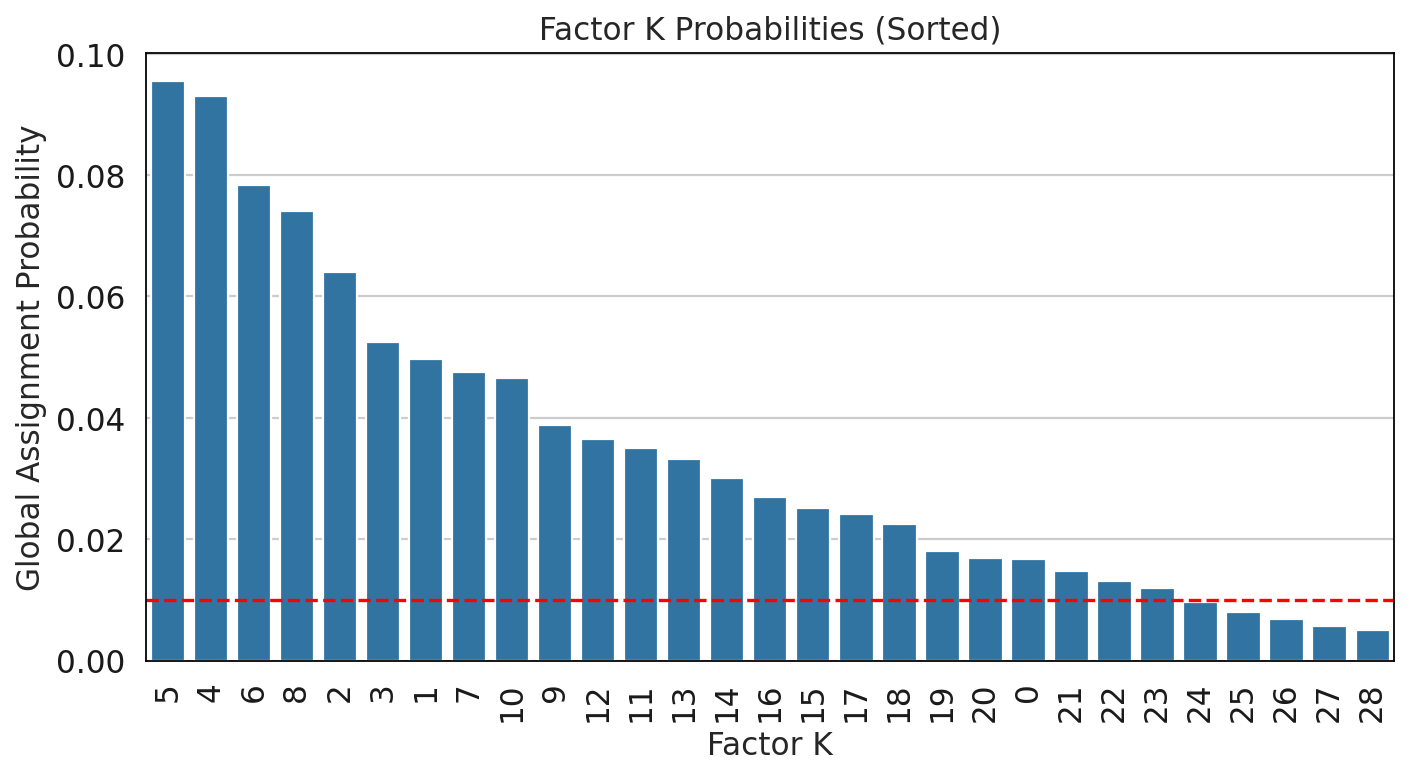

In [67]:
# Make a quick barplot of PI 
PI_df = pd.DataFrame(PI, columns=["PI"])
PI_df["Factor"] = PI_df.index
PI_df = PI_df.sort_values(by="PI", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Factor", y="PI", data=PI_df, order=PI_df["Factor"])
plt.title("Factor K Probabilities (Sorted)")
plt.xlabel("Factor K")
plt.ylabel("Global Assignment Probability")
plt.axhline(0.01, color="red", linestyle="--")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors

In [68]:
# Add PHI to adata 
adata.obsm["X_PHI"] = PHI
sc.pp.neighbors(adata, use_rep="X_PHI")
sc.tl.umap(adata)

In [69]:
adata.obs

,Main_cluster_name_wkmeans,Main_cluster_name,Type,primer,cell_id_index,Cleaned_cluster_name,highlight
Main_cluster_name_wkmeans,,,,,,,
Astrocytes_5xFAD_1032,Astrocytes_5xFAD_1032,Astrocytes,5xFAD,RH,0,Astrocytes,Other
Astrocytes_5xFAD_1109,Astrocytes_5xFAD_1109,Astrocytes,5xFAD,RH,1,Astrocytes,Other
Astrocytes_APOE4_TREM2_1766,Astrocytes_APOE4_TREM2_1766,Astrocytes,APOE4_TREM2,RH,2,Astrocytes,Other
Bergmann_glia_5xFAD_2298,Bergmann_glia_5xFAD_2298,Bergmann_glia,5xFAD,RH,3,Astrocytes,Other
Cerebellum_granule_neurons_21mo_366,Cerebellum_granule_neurons_21mo_366,Cerebellum_granule_neurons,21mo,RH,4,Neurons,Other
...,...,...,...,...,...,...,...
Striatal_neurons_1_3mo_98,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3mo,RH,9916,Neurons,Other
Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,RH,9917,Neurons,Other
Striatal_neurons_1_5xFAD_928,Striatal_neurons_1_5xFAD_928,Striatal_neurons_1,5xFAD,RH,9918,Neurons,Other


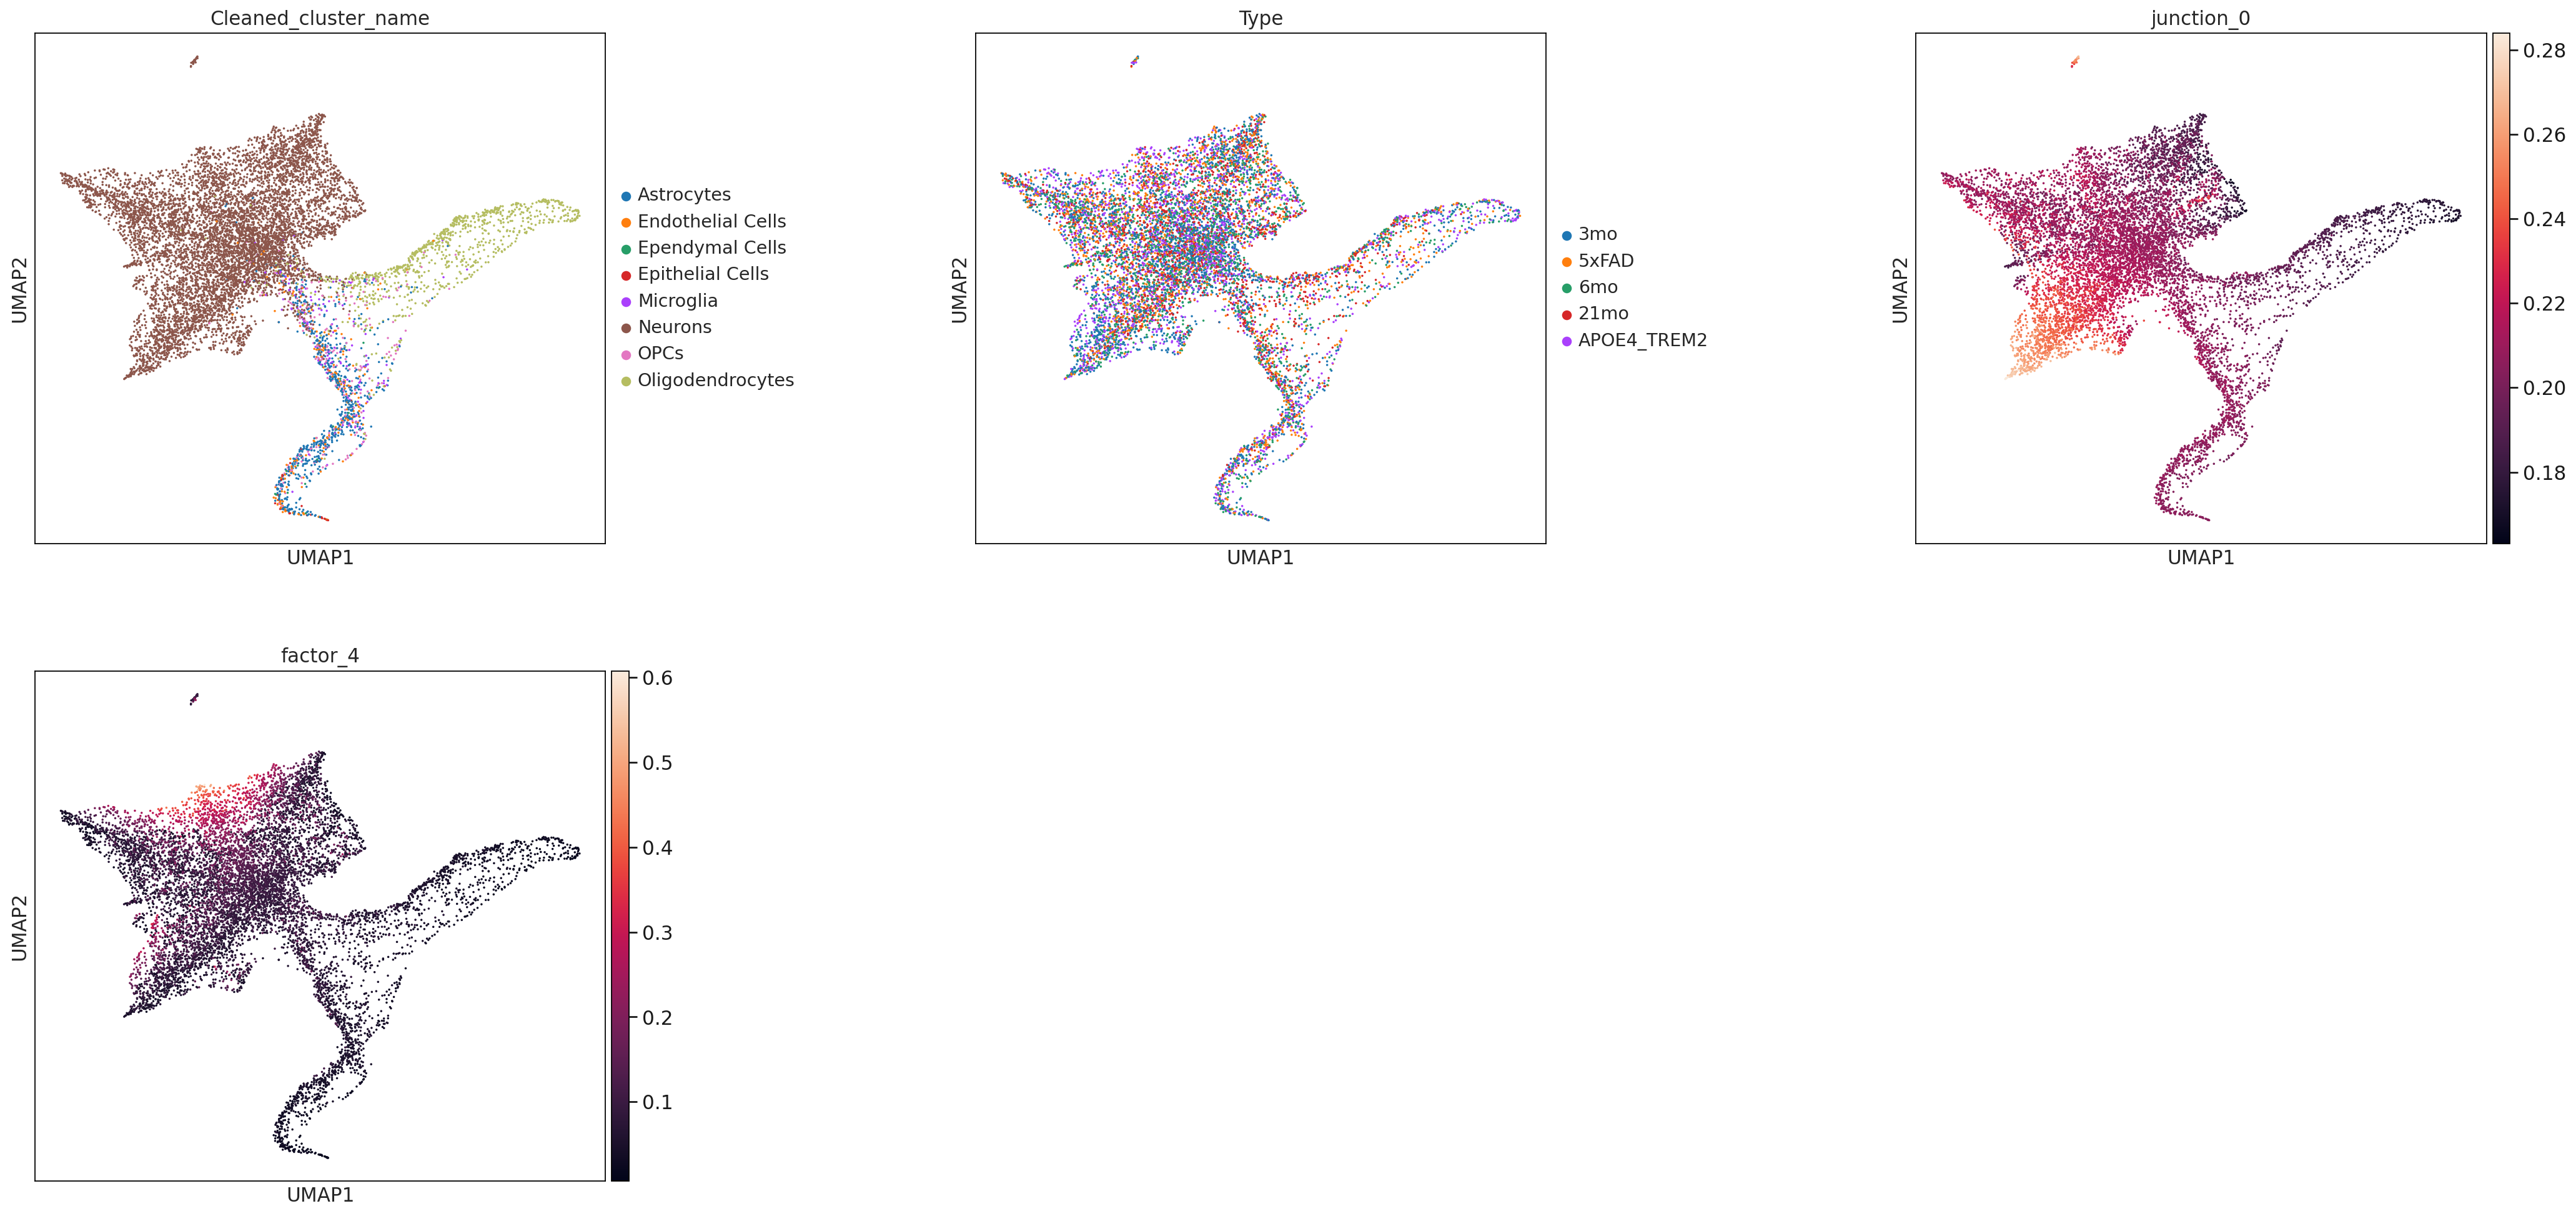

In [151]:
plot_umap_with_junctions_and_factors(adata, junction_ids=[0], factors=[4], PHI_matrix=PHI, meta_columns=["Cleaned_cluster_name", "Type"], size=10, ncols=3, wspace=0.5)

### LeafletFA vs aging regression 

In [71]:
# Define the target variable
y = adata.obs["Cleaned_cluster_name"]
X = adata.obsm["X_PHI"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

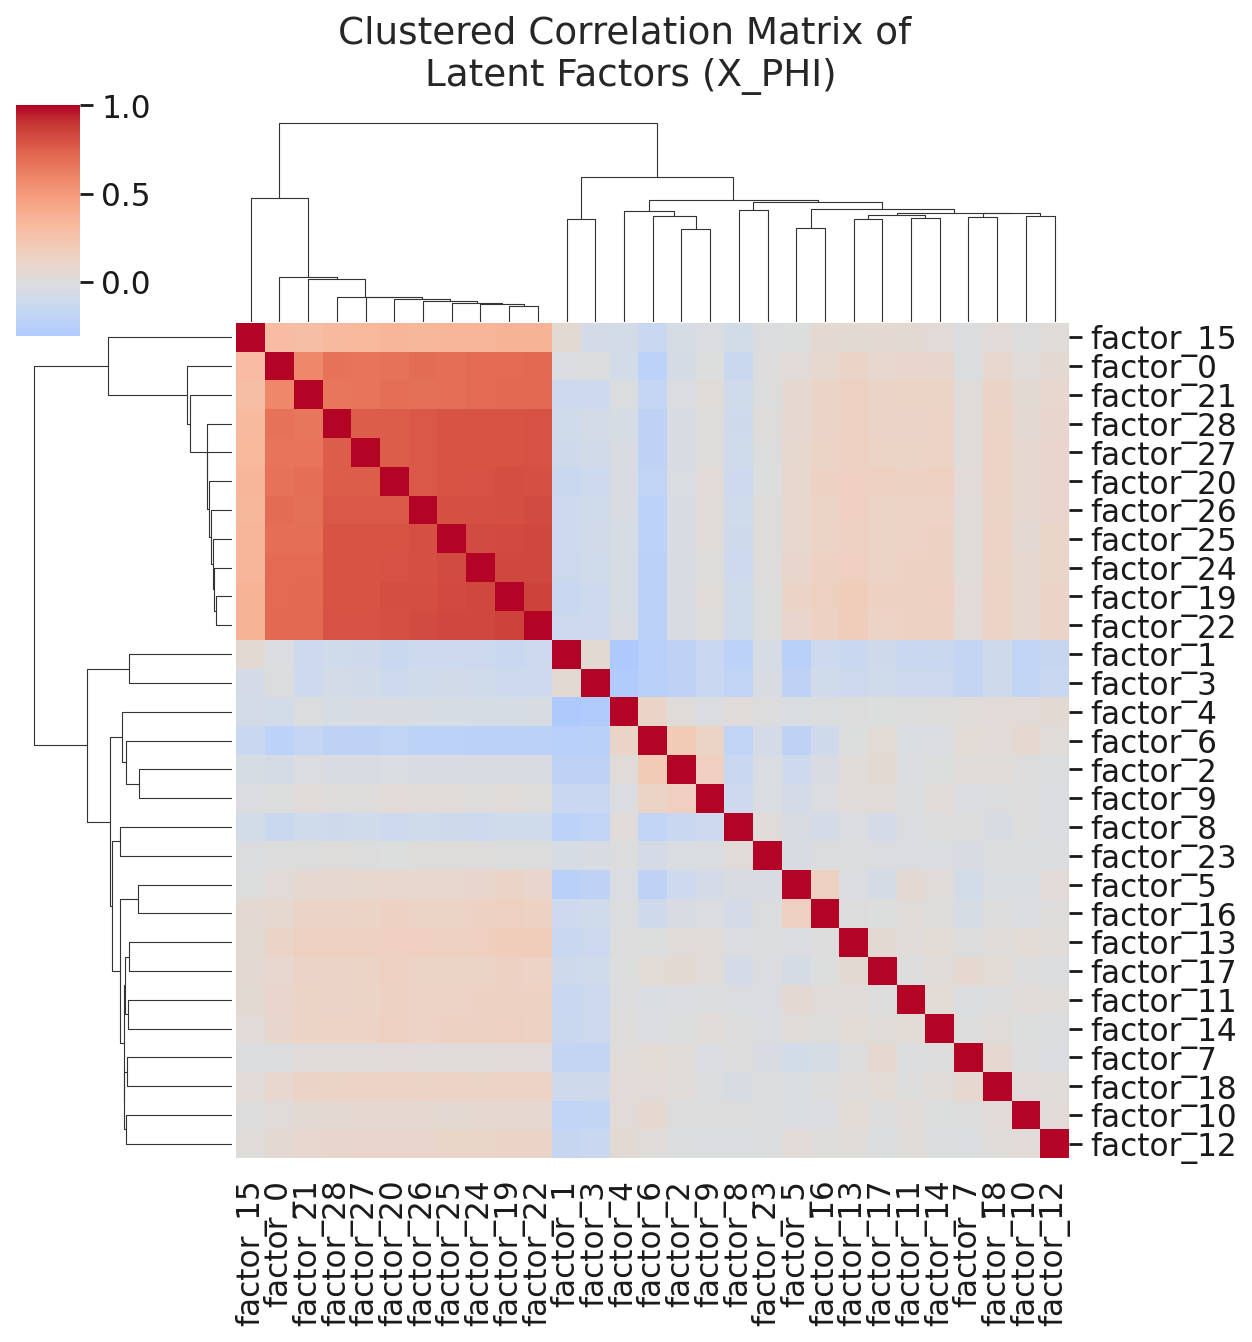

In [72]:
# Compute correlation matrix
corr_matrix = np.corrcoef(X_train.T)  # K × K

# Generate factor labels
factor_labels = [f"factor_{i}" for i in range(X_train.shape[1])]

sns.clustermap(corr_matrix, cmap="coolwarm", center=0, xticklabels=factor_labels, yticklabels=factor_labels, figsize=(8, 8))

# Add title
plt.suptitle("Clustered Correlation Matrix of \nLatent Factors (X_PHI)", y=1.05)
plt.show()

In [73]:
# Extract factor matrix
X_PHI = adata.obsm["X_PHI"]

# Convert X_PHI to a DataFrame and add age labels
factor_df = pd.DataFrame(X_PHI, columns=factor_labels, index=adata.obs.index)
factor_df

,factor_0,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,...,factor_19,factor_20,factor_21,factor_22,factor_23,factor_24,factor_25,factor_26,factor_27,factor_28
Main_cluster_name_wkmeans,,,,,,,,,,,,,,,,,,,,,
Astrocytes_5xFAD_1032,0.004021,0.648053,0.013969,0.126687,0.018541,0.021323,0.015876,0.013426,0.020732,0.009079,...,0.005375,0.005247,0.003559,0.004488,0.002919,0.003148,0.002166,0.002013,0.001475,0.001350
Astrocytes_5xFAD_1109,0.014598,0.384222,0.058779,0.063584,0.054571,0.051997,0.030872,0.029022,0.032853,0.014664,...,0.010160,0.009807,0.008711,0.007156,0.006866,0.005885,0.005368,0.003829,0.003227,0.003094
Astrocytes_APOE4_TREM2_1766,0.002719,0.790875,0.012801,0.025846,0.020671,0.014699,0.007800,0.006360,0.008712,0.007747,...,0.004145,0.002992,0.002371,0.002707,0.001738,0.001836,0.001559,0.001624,0.000936,0.000863
Bergmann_glia_5xFAD_2298,0.005788,0.631108,0.024618,0.031548,0.031201,0.038638,0.023845,0.015175,0.026627,0.013300,...,0.006983,0.006719,0.006451,0.006314,0.005751,0.004270,0.004022,0.003012,0.002296,0.001619
Cerebellum_granule_neurons_21mo_366,0.013373,0.033823,0.066736,0.047864,0.096459,0.138842,0.118616,0.027787,0.055509,0.028821,...,0.013049,0.013379,0.012544,0.010305,0.008901,0.008798,0.006744,0.006622,0.005550,0.005784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Striatal_neurons_1_3mo_98,0.005032,0.009258,0.209182,0.019452,0.232078,0.026531,0.186156,0.018622,0.013486,0.038672,...,0.009502,0.009400,0.004707,0.006286,0.003896,0.003554,0.002934,0.002955,0.002098,0.001879
Striatal_neurons_1_5xFAD_1572,0.001587,0.003418,0.047710,0.005442,0.066479,0.013814,0.289589,0.006121,0.017268,0.373383,...,0.005790,0.004221,0.005310,0.003859,0.003342,0.001874,0.001874,0.001930,0.001760,0.001199
Striatal_neurons_1_5xFAD_928,0.004328,0.013437,0.323654,0.021581,0.050314,0.081148,0.125822,0.050304,0.033756,0.036474,...,0.009227,0.009619,0.008848,0.006648,0.009339,0.004851,0.006661,0.003332,0.002293,0.002278


/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = data_melted.groupby(['Factor', age_column])['Contribution'].median().reset_index()


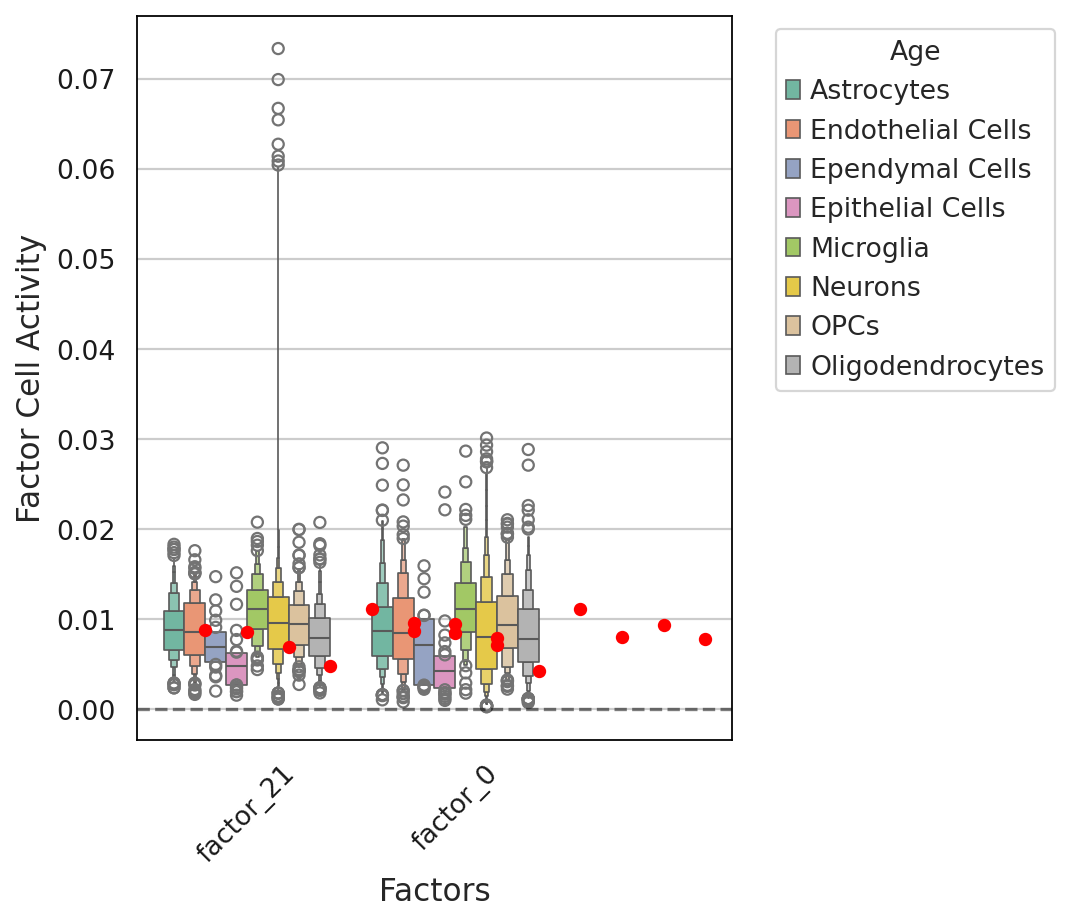

In [74]:
plot_top_factor_distributions(adata, [21, 0], age_column="Cleaned_cluster_name")

In [75]:
# confirm that all rows sum to 1 in PHI 
assert np.allclose(np.sum(PHI, axis=1), 1.0)

### Train multiclass model to predict cell type 

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Cleaned_cluster_name Prediction Accuracy: 0.9122


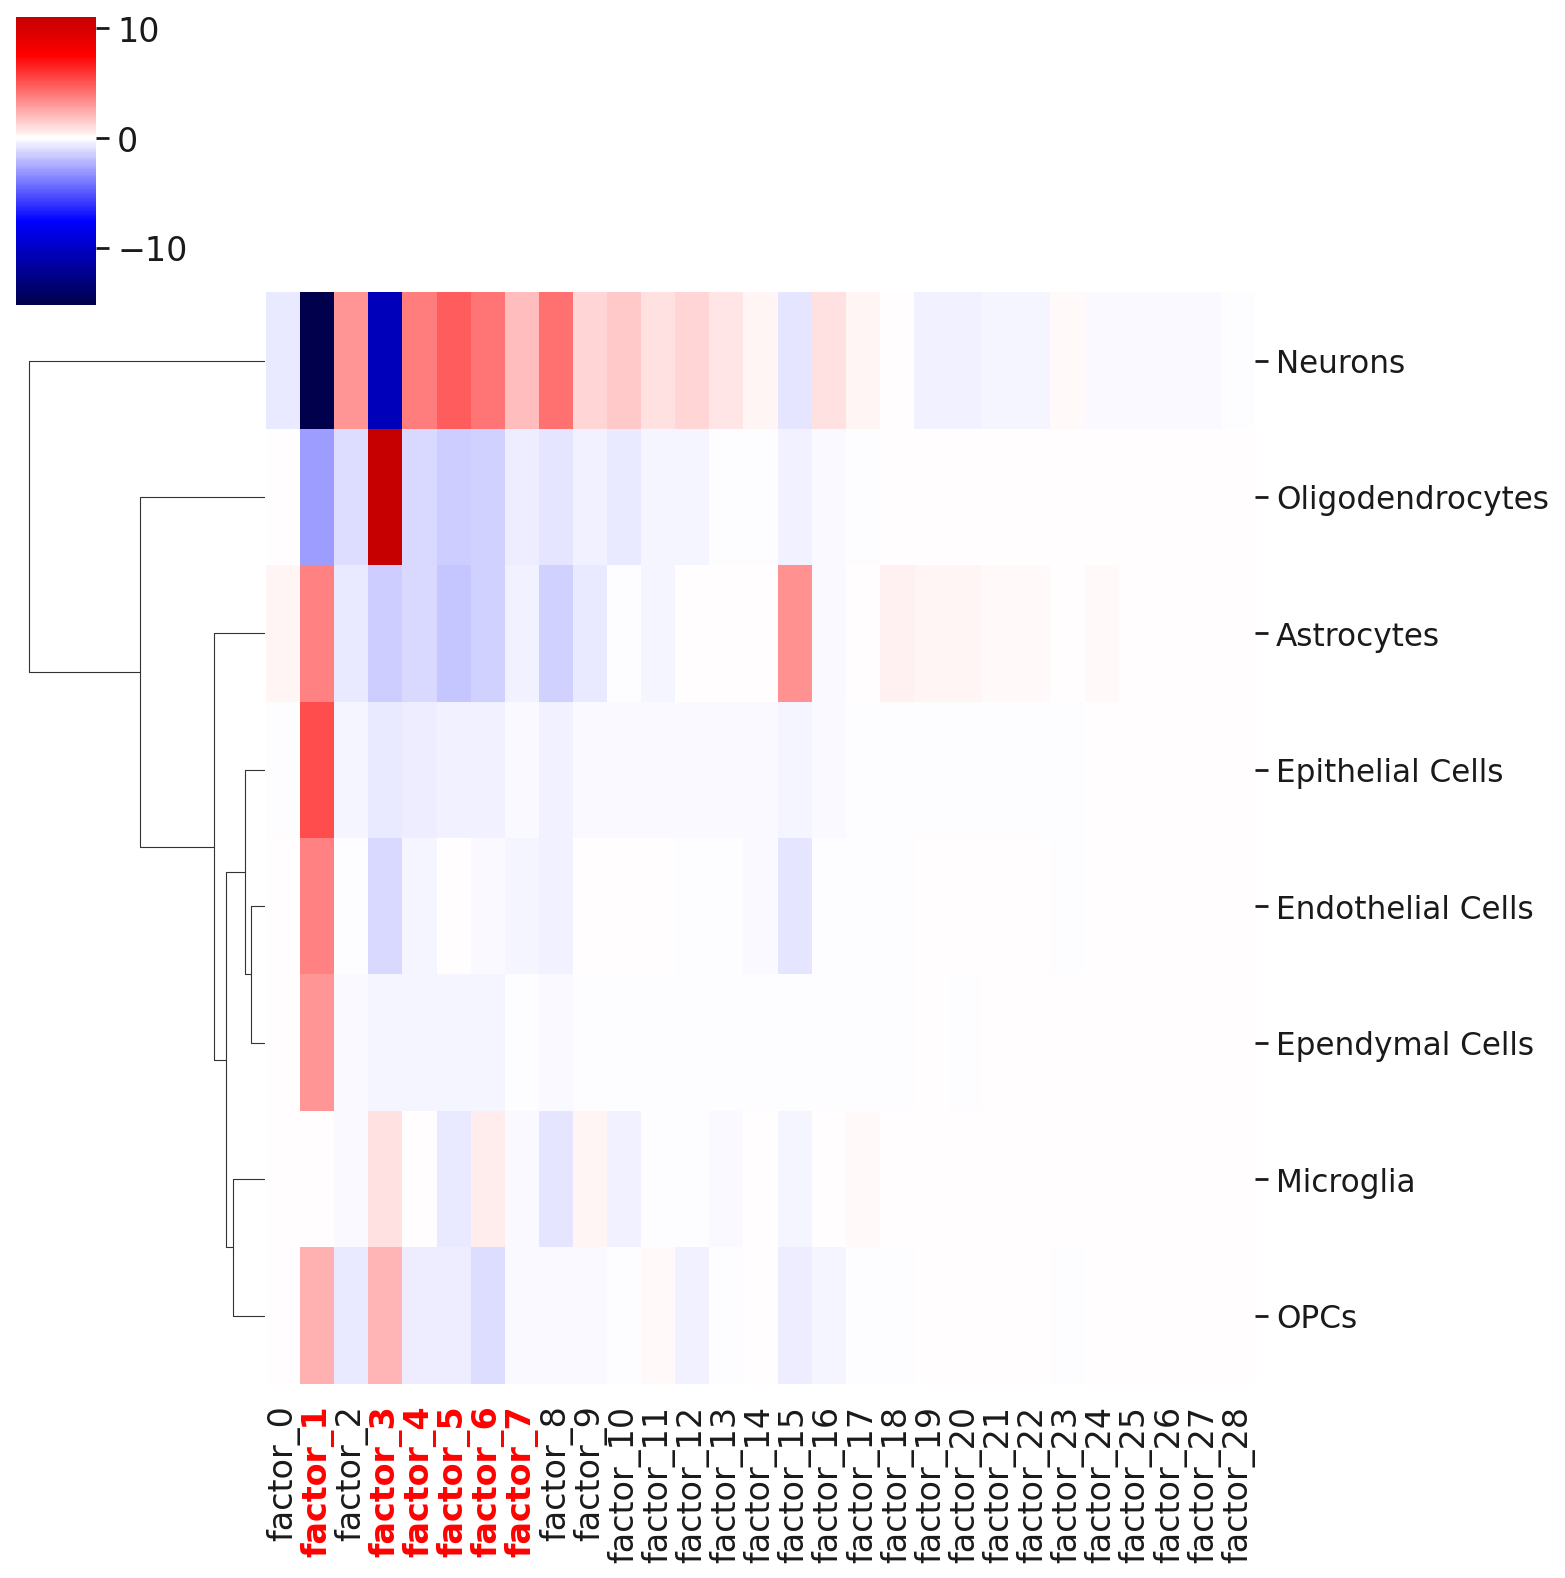

In [76]:
cell_type_accuracy, model, encoder, coef_df_cell_type = logistic_regression_feature_prediction_simple(adata, "Cleaned_cluster_name")
plot_clustermap(coef_df_cell_type, highlighted_factors=["factor_1", "factor_3", "factor_4", "factor_5", "factor_6", "factor_7"], cmap="seismic", figsize=(10, 10), center=0)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Type Prediction Accuracy: 0.2731


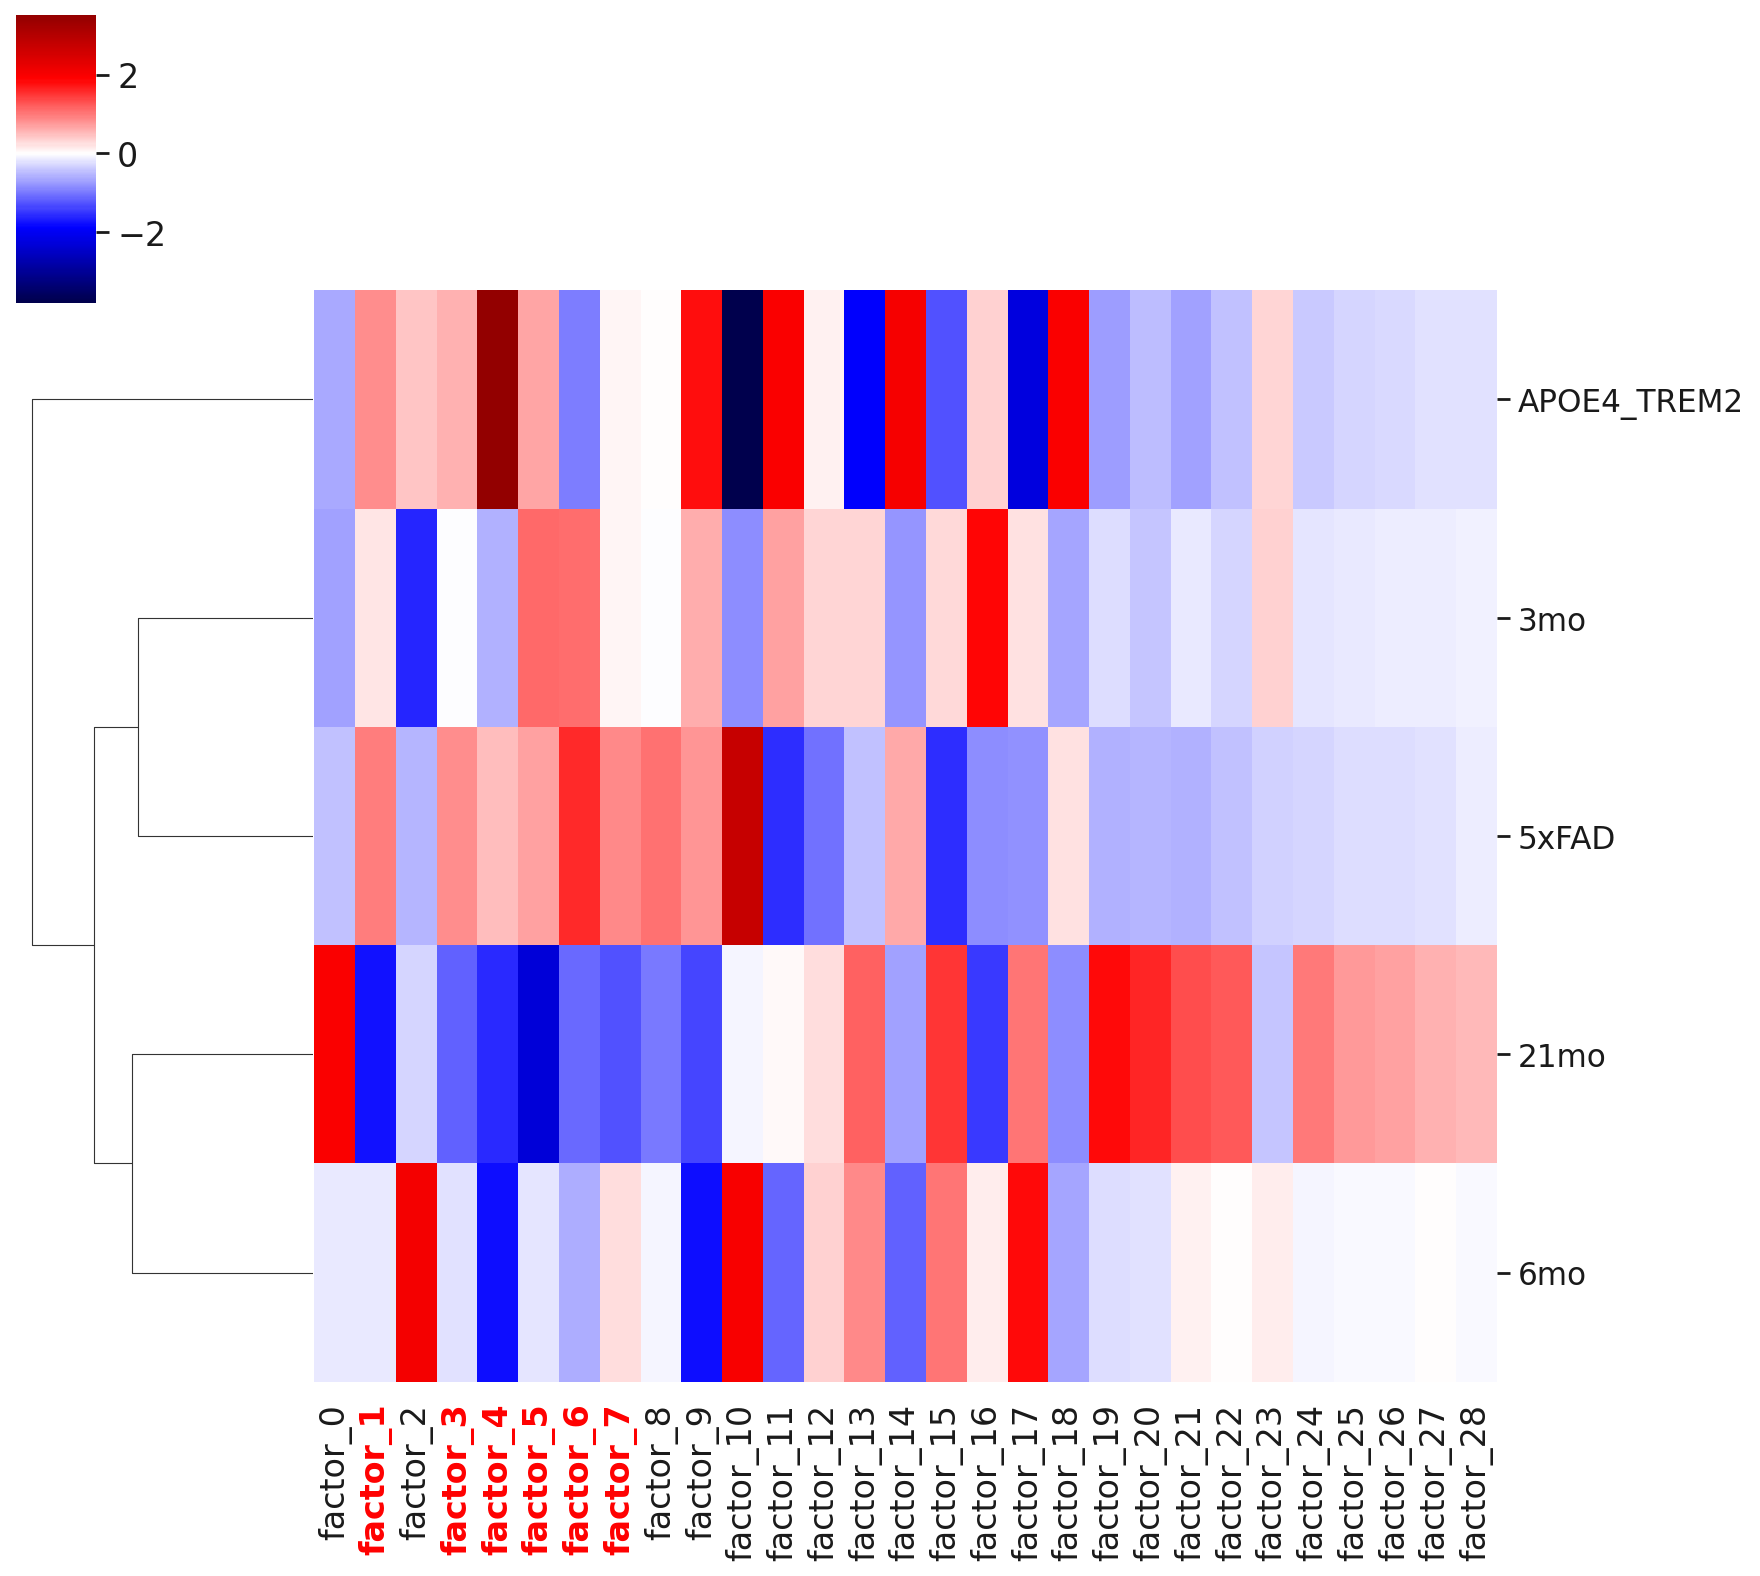

In [77]:
cell_type_accuracy, model, encoder, coef_df_type = logistic_regression_feature_prediction_simple(adata, "Type")
plot_clustermap(coef_df_type, highlighted_factors=["factor_1", "factor_3", "factor_4", "factor_5", "factor_6", "factor_7"], cmap="seismic", figsize=(10, 10), center=0)

In [78]:
adata.obs.Cleaned_cluster_name.unique()

['Astrocytes', 'Neurons', 'Microglia', 'OPCs', 'Oligodendrocytes', 'Endothelial Cells', 'Epithelial Cells', 'Ependymal Cells']
Categories (8, object): ['Astrocytes', 'Endothelial Cells', 'Ependymal Cells', 'Epithelial Cells', 'Microglia', 'Neurons', 'OPCs', 'Oligodendrocytes']

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = subset_cells.obs.groupby(group_column)[feature].median()
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:749: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset_cells.obs.groupby(group_column)[feature].mean()


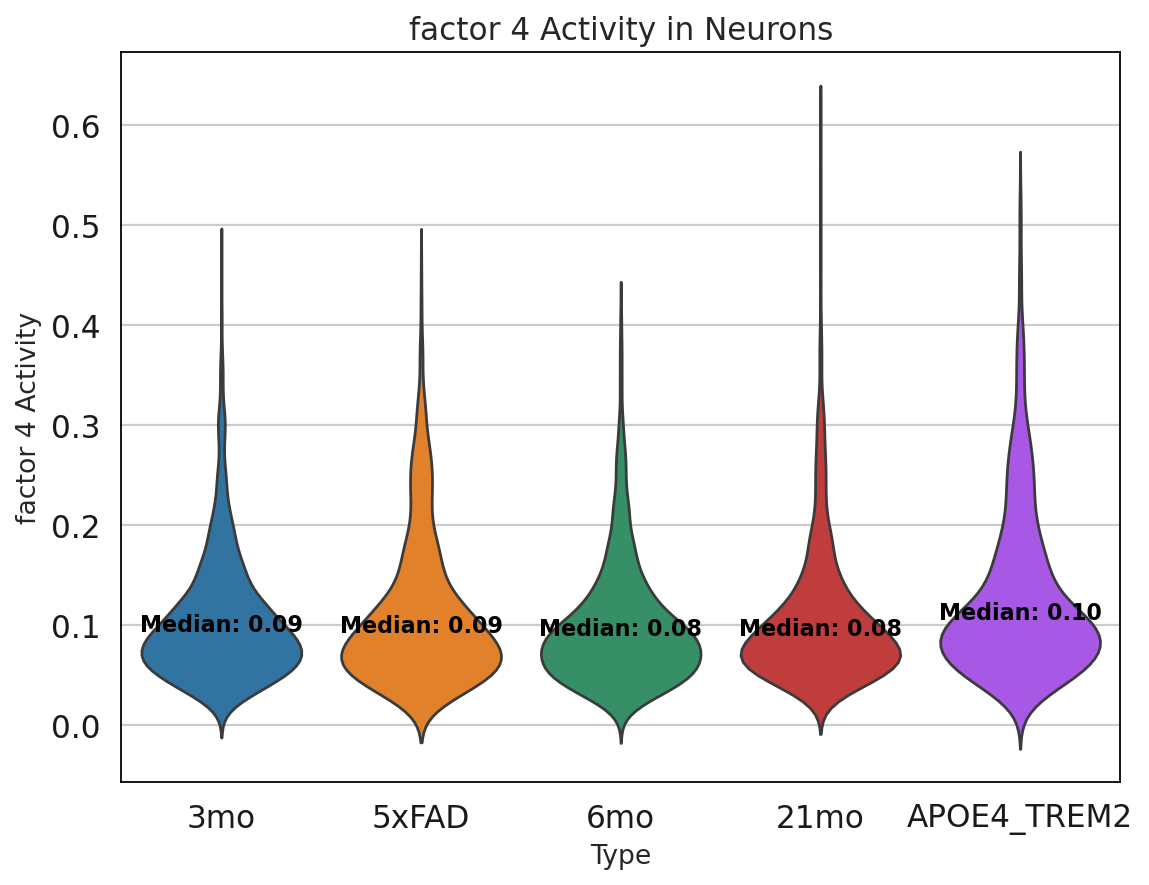

In [101]:
plot_violin_by_cell_type(adata, feature="factor", factor_idx=4, group_column="Type", size=(8,6), cell_type="Neurons", cell_type_column="Cleaned_cluster_name")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model Accuracy: 0.2832
Classification Report:
               precision    recall  f1-score   support

        21mo       0.31      0.15      0.20       345
         3mo       0.27      0.56      0.36       486
       5xFAD       0.38      0.02      0.04       314
         6mo       0.25      0.20      0.23       417
 APOE4_TREM2       0.33      0.36      0.34       419

    accuracy                           0.28      1981
   macro avg       0.31      0.26      0.23      1981
weighted avg       0.30      0.28      0.25      1981



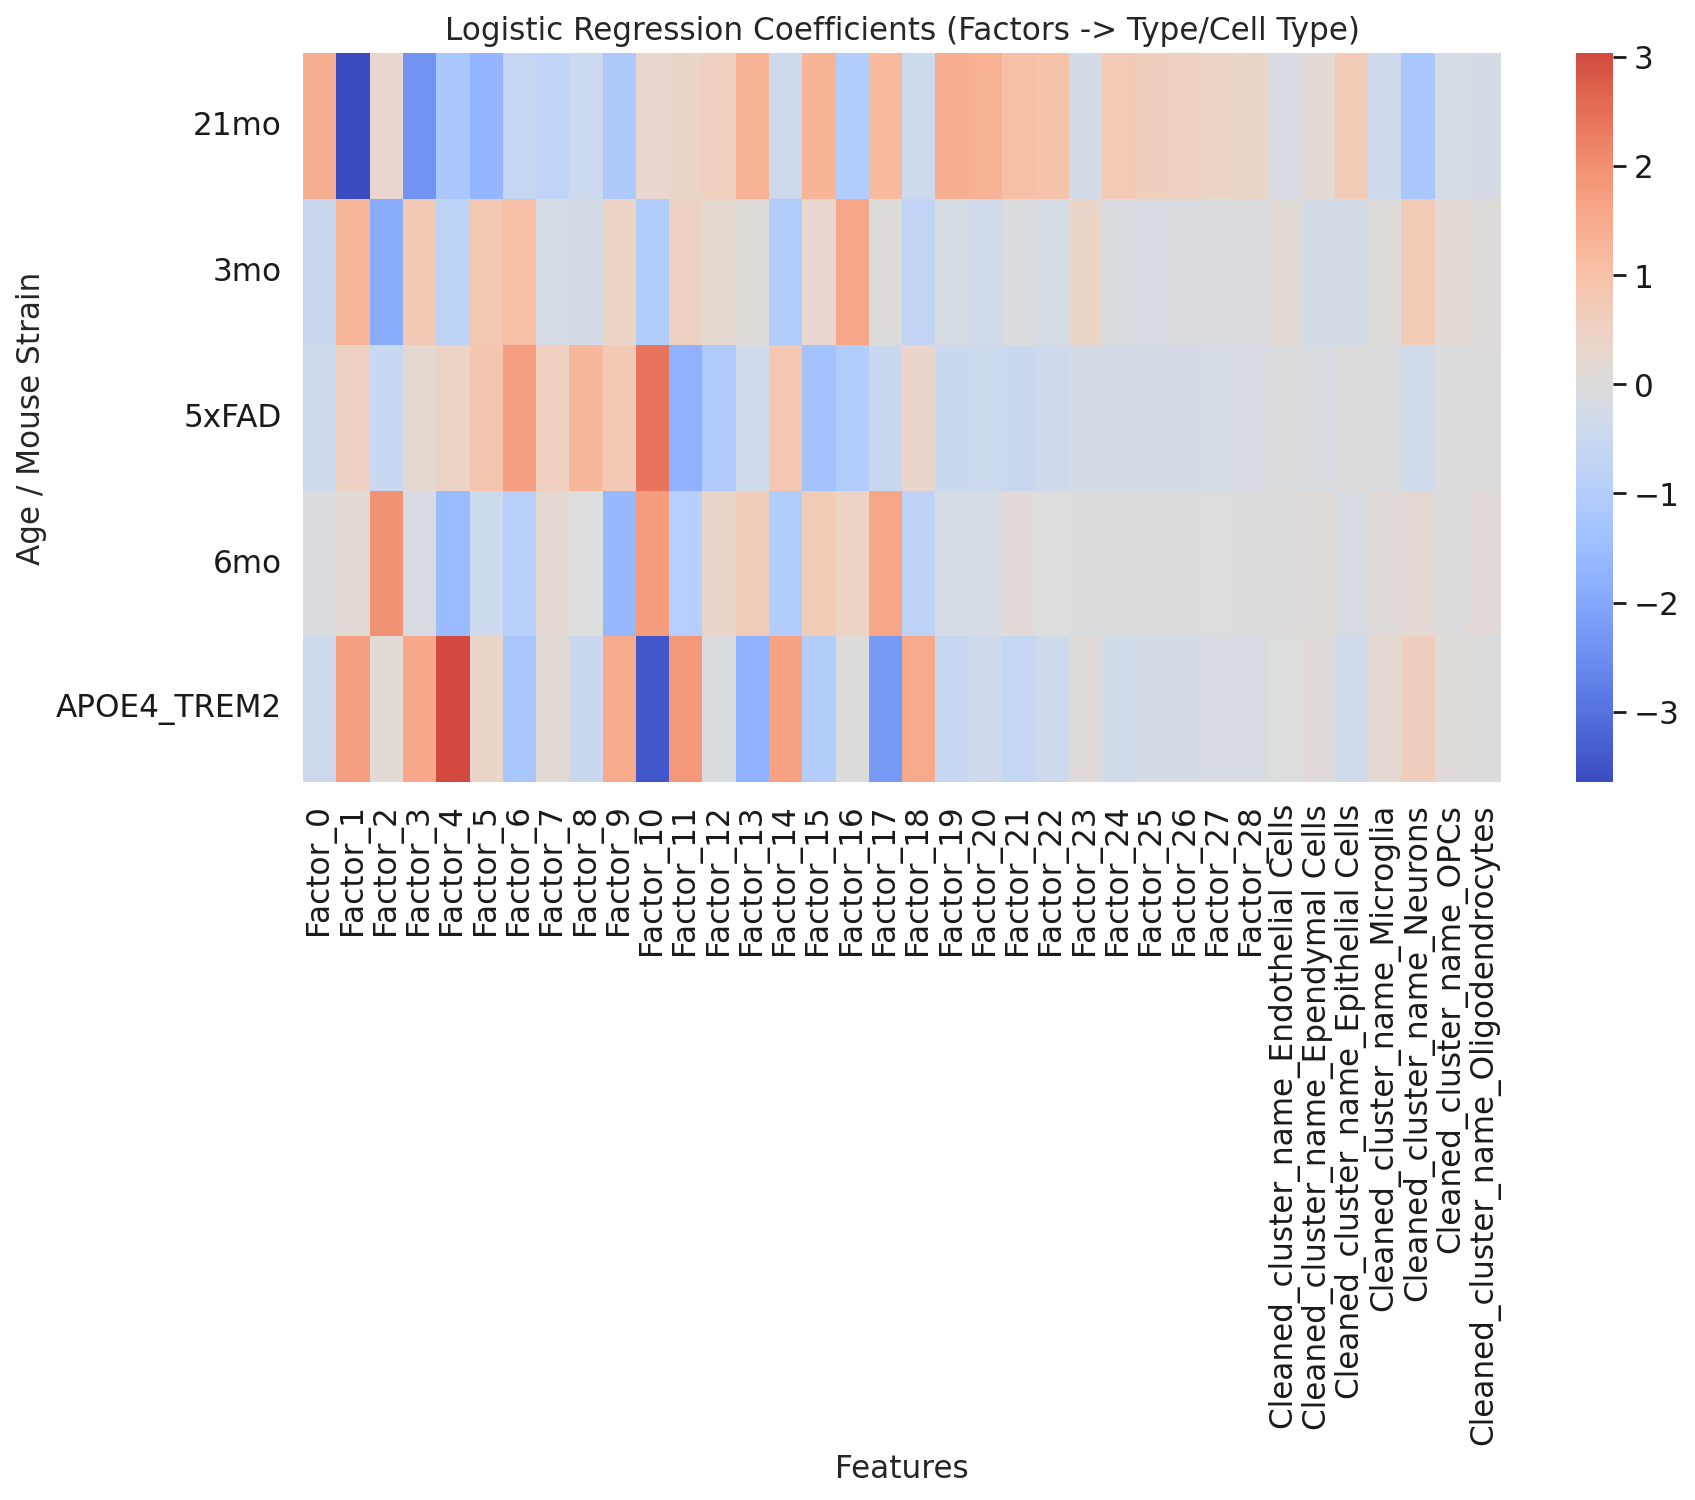

In [97]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define the target variable
y = adata.obs["Type"]

# Extract factor activities
X_factors = adata.obsm["X_PHI"]

# Extract and one-hot encode the covariate (Cleaned_cluster_name)
covariate = adata.obs["Cleaned_cluster_name"].values.reshape(-1, 1)  # Ensure it's 2D
encoder = OneHotEncoder(drop="first")  # Drop first category to avoid multicollinearity
X_covariate = encoder.fit_transform(covariate)
# Convert sparse matrix to dense before concatenation
X_covariate = X_covariate.toarray()  

# Concatenate factor activities with encoded covariates
X = np.hstack((X_factors, X_covariate))  # Now both are 2D

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model = LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs")
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

# Get the class labels (Types or Cell Types)
classes = model.classes_  # Unique types (e.g., cell types)

# Get coefficient matrix (shape: [n_classes, n_features])
coefficients = model.coef_  # Each row corresponds to a class, each column to a feature

# Extract feature names (Factor names + Covariate names)
factor_names = [f"Factor_{i}" for i in range(X_factors.shape[1])]  # e.g., Factor_0, Factor_1, ...
covariate_names = encoder.get_feature_names_out(["Cleaned_cluster_name"]).tolist()

feature_names = factor_names + covariate_names  # Combine factor & covariate names

# Convert to DataFrame
coef_df = pd.DataFrame(coefficients, columns=feature_names, index=classes)

# Display coefficients
plt.figure(figsize=(12, 6))
sns.heatmap(coef_df, cmap="coolwarm", center=0, annot=False, fmt=".2f")
plt.title("Logistic Regression Coefficients (Factors -> Type/Cell Type)")
plt.xlabel("Features")
plt.ylabel("Age / Mouse Strain")
plt.xticks(rotation=90)
plt.show()

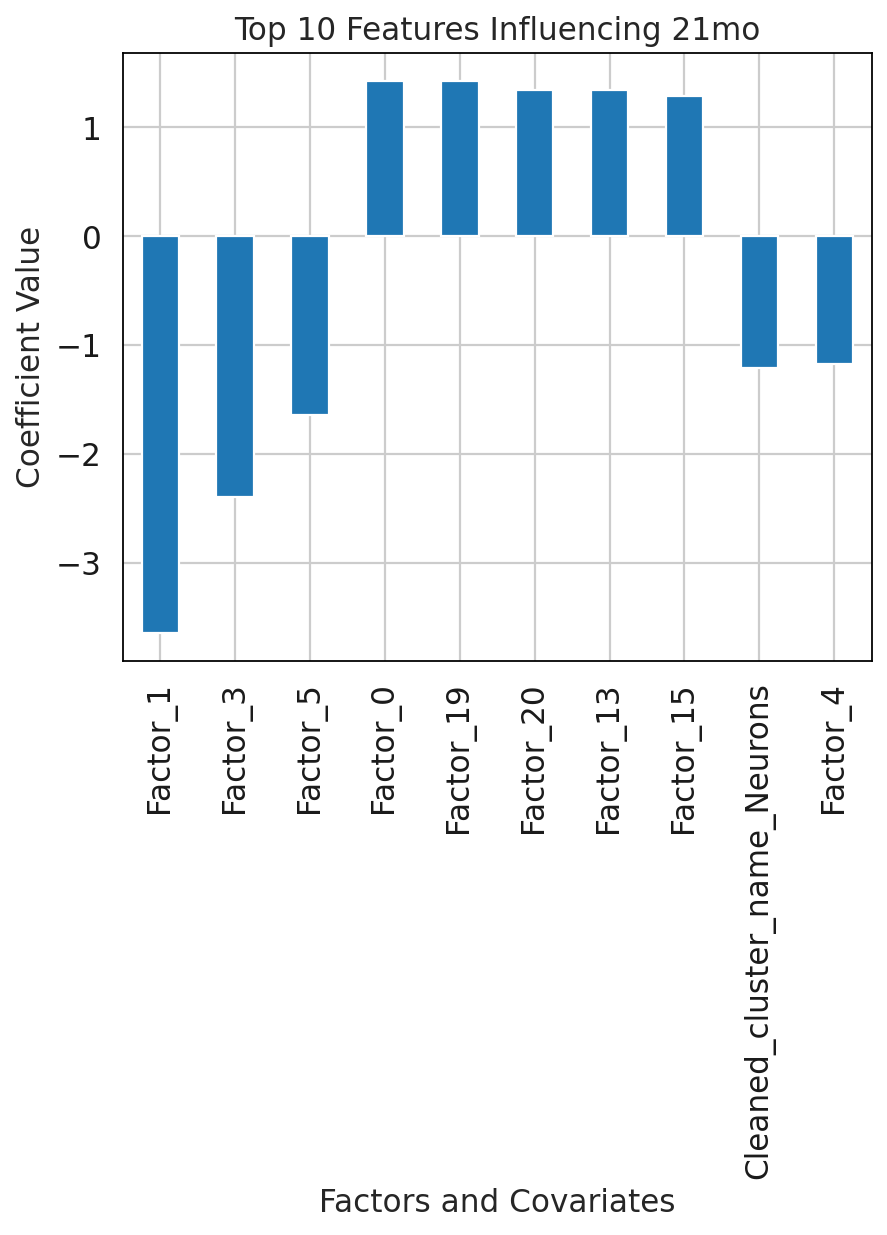

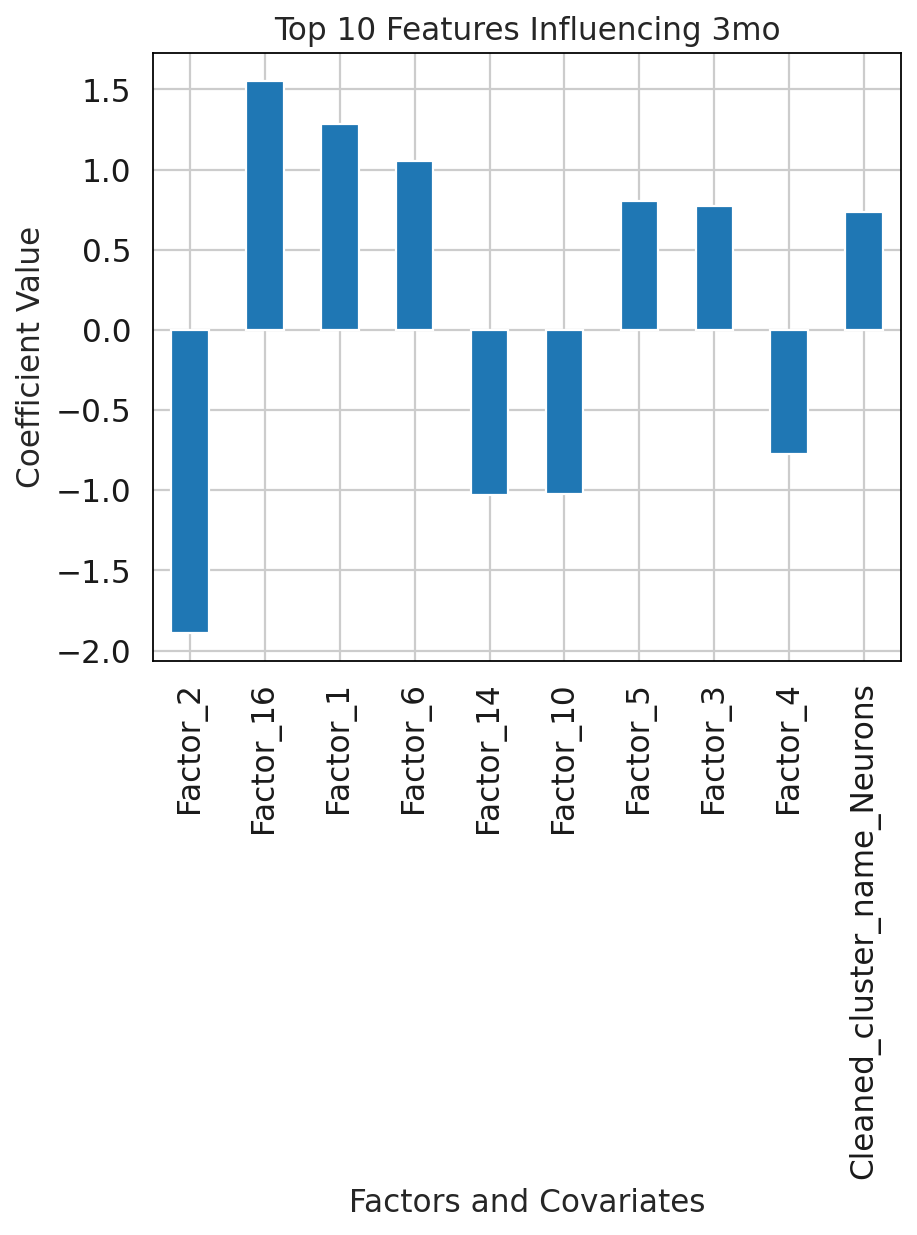

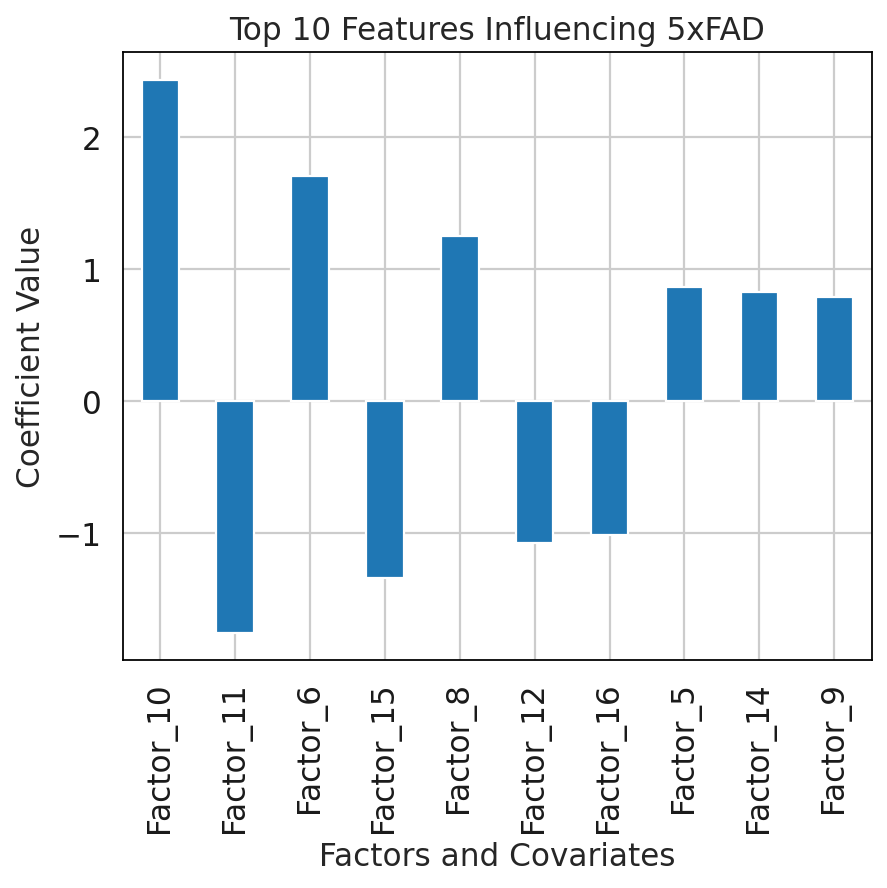

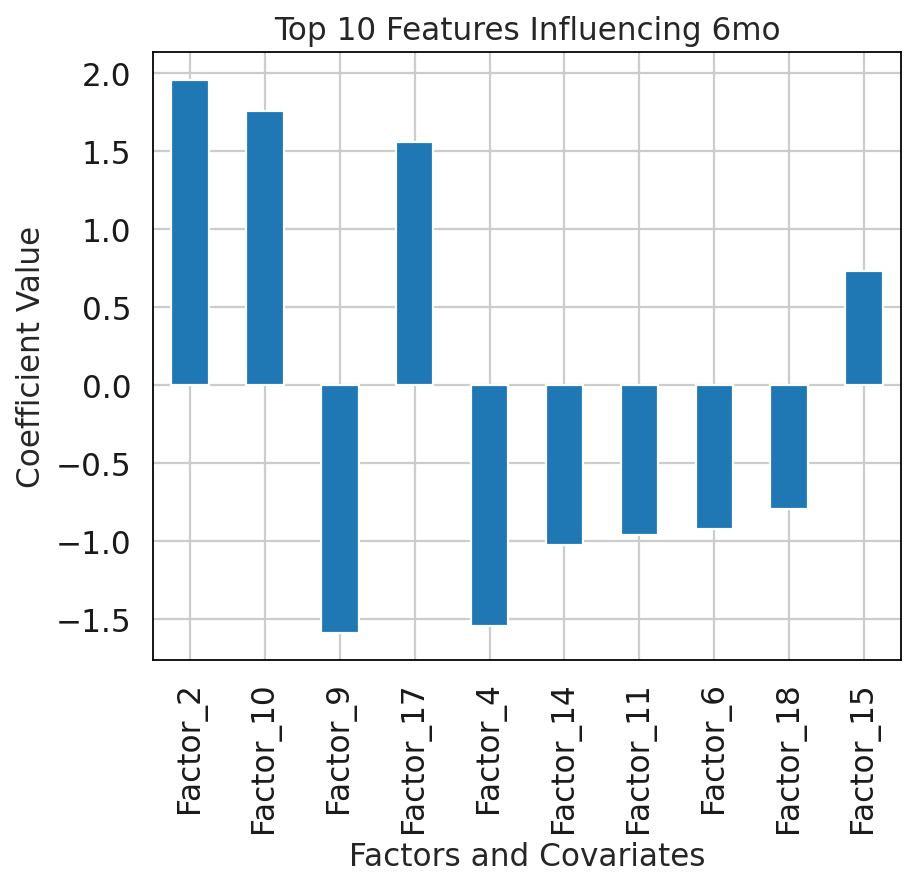

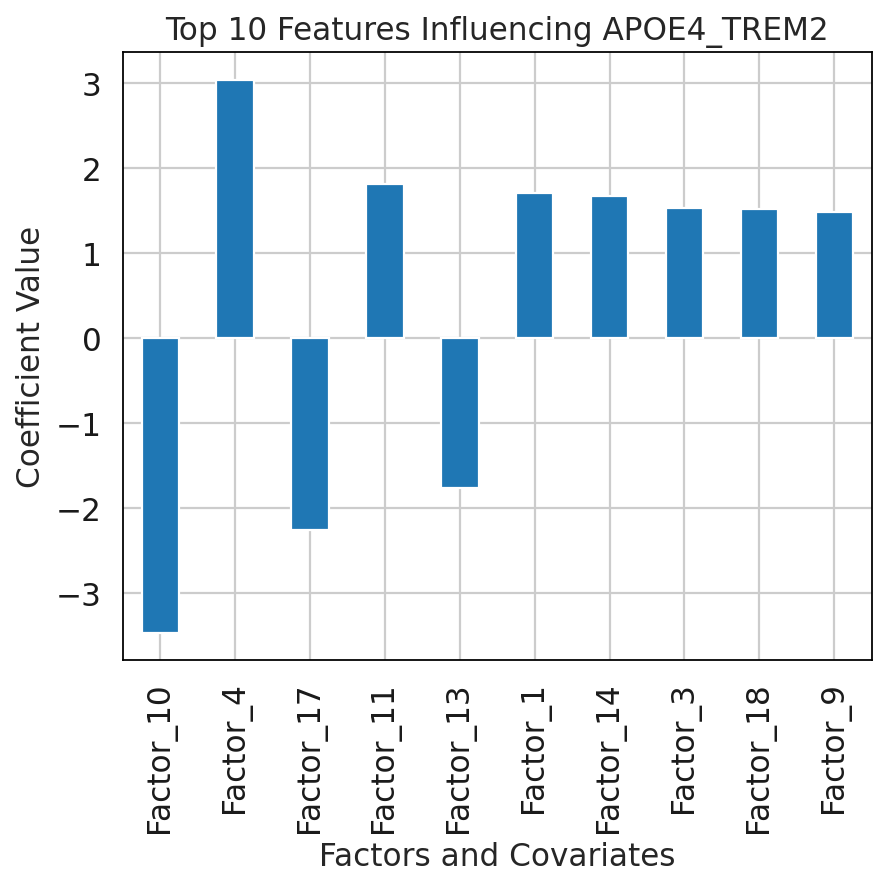

In [150]:
for class_label in coef_df.index:
    plt.figure(figsize=(6, 5))
    coef_df.loc[class_label].sort_values(key=abs, ascending=False).head(10).plot(kind="bar")
    plt.title(f"Top 10 Features Influencing {class_label}")
    plt.ylabel("Coefficient Value")
    plt.xlabel("Factors and Covariates")
    plt.xticks(rotation=90)
    plt.show()


### Load gene expression 

In [ ]:
ge_adata = ""

# Load the gene expression anndata object
ge_adata = ad.read_h5ad(ge_adata)

In [ ]:
accuracies, models, label_encoder, coefficients_dfs = logistic_regression_feature_prediction(
    splice_adata=adata,
    gene_expression_adata=ge_adata,
    feature="age",
    K=50,
    n_pcs=50,
    covariate_column="tissue",
    test_size=0.2
)

In [ ]:
print(accuracies)

### Differential Splicing Analysis 

In [104]:
# Get top variable junctions from PSI_df
top_junctions = PSI_df.sort_values(by="PSI_variance", ascending=False).head(30000).junction_id_index.values

In [105]:
top_junctions

array([ 2209,  2208,  7759, ...,  1727, 11360, 11351])

## factor 4

In [106]:
top_fact_juncs = [] 
effect_size=0.2
factor_idx = 4
for j in tqdm(top_junctions):
    results_dict = ds.compute_psi_effect_size(
        psi_samples, factor_idx, j, min_effect_size=effect_size
    )
    top_fact_juncs.append(results_dict)
# Convert to DataFrame
top_fact_juncs_df = pd.DataFrame(top_fact_juncs)
# Compute significance
top_fact_juncs_df_SIG = ds.compute_junctions_significance_psi(top_fact_juncs_df, fdr_threshold=0.05, min_effect_size=effect_size)

100%|██████████| 13402/13402 [00:01<00:00, 7065.17it/s]


Found 1282 significant junctions with effect size > 0.2 at FDR < 0.05


global_aging_genes
False    1225
True       57
Name: count, dtype: int64


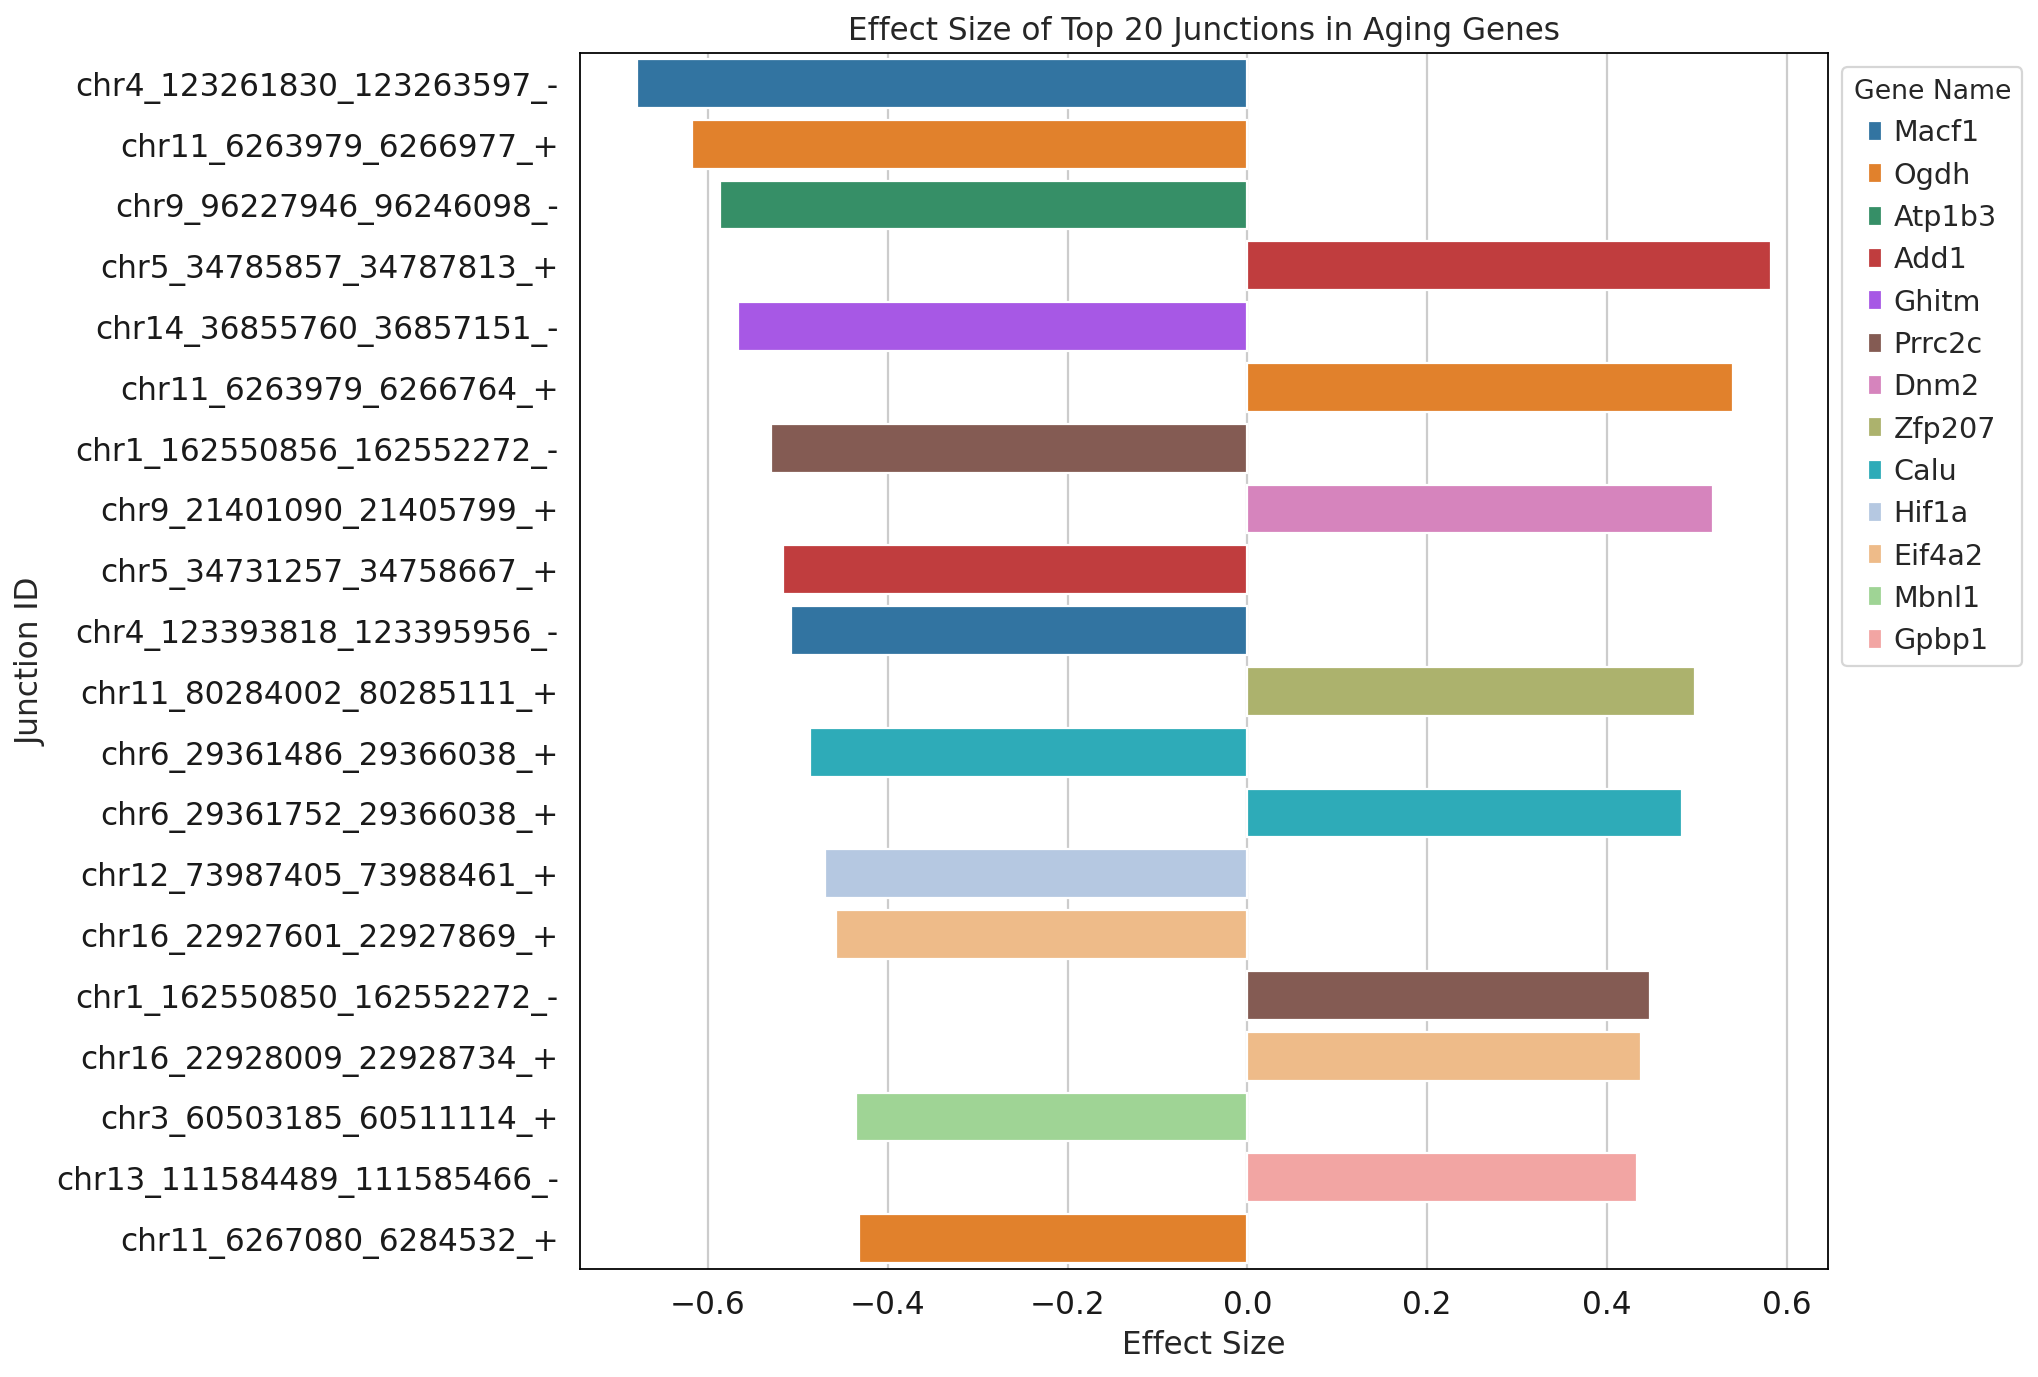

In [107]:
top_fact_juncs_df_SIG["junction_id_index"] = top_fact_juncs_df_SIG["junction_idx"].values 
# merge with adata.var 
top_fact_juncs_df_SIG = top_fact_juncs_df_SIG.merge(adata.var, on="junction_id_index")
# sort by SIG hits and decreasing abs effect size
top_fact_juncs_df_SIG = top_fact_juncs_df_SIG.sort_values(by=["significant", "abs_effect_size"], ascending=[False, False])
top_fact_juncs_df_SIG["log10FDR"] = -np.log(top_fact_juncs_df_SIG["fdr_curve"] + 1e-10)
# Let's take top 50 junctions and summarize their effect size in barplot and color by whether they are in known aging genes 
# keep just sig ones 
SIG_only = top_fact_juncs_df_SIG[top_fact_juncs_df_SIG["significant"]]

# now sort by abs effect size
SIG_only = SIG_only.sort_values(by="abs_effect_size", ascending=False)
print(SIG_only.global_aging_genes.value_counts())

aging_genes = SIG_only[SIG_only['global_aging_genes'] == True]

# Select the top 50 junctions with highest absolute effect size
top_50_junctions = aging_genes.nlargest(20, "abs_effect_size")

# convert gene_name to str 
top_50_junctions["gene_name"] = top_50_junctions["gene_name"].astype(str)

# Plot
plt.figure(figsize=(10, 10))
sns.barplot(x="effect_size", y="junction_id", data=top_50_junctions, hue="gene_name", dodge=False)

# Titles and labels
plt.title("Effect Size of Top 20 Junctions in Aging Genes")
plt.xlabel("Effect Size")
plt.ylabel("Junction ID")
plt.legend(title="Gene Name", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = subset_cells.obs.groupby(group_column)[feature].median()
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:749: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset_cells.obs.groupby(group_column)[feature].mean()


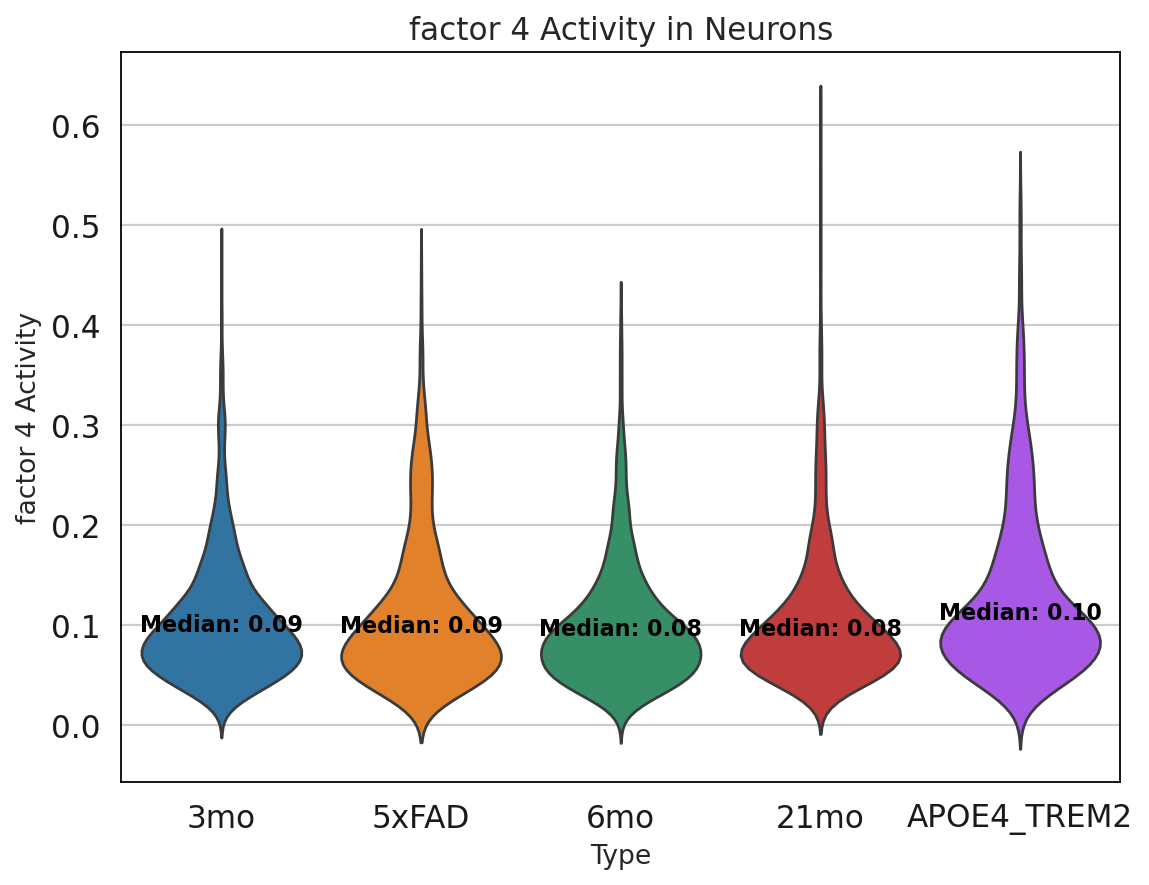

In [110]:
plot_violin_by_cell_type(adata, feature="factor", factor_idx=4, cell_type_column="Cleaned_cluster_name", cell_type="Neurons", group_column="Type", size=(8,6))

## factor 4

In [111]:
top_fact_juncs = [] 
factor_idx = 4
effect_size = 0.2
for j in tqdm(top_junctions):
    results_dict = ds.compute_psi_effect_size(
        psi_samples, factor_idx, j, min_effect_size=effect_size
    )
    top_fact_juncs.append(results_dict)
# Convert to DataFrame
top_fact_juncs_df = pd.DataFrame(top_fact_juncs)
# Compute significance
top_fact_juncs_df_SIG = ds.compute_junctions_significance_psi(top_fact_juncs_df, fdr_threshold=0.05, min_effect_size=effect_size)

100%|██████████| 13402/13402 [00:01<00:00, 7349.36it/s]

Found 1282 significant junctions with effect size > 0.2 at FDR < 0.05


global_aging_genes
False    1225
True       57
Name: count, dtype: int64


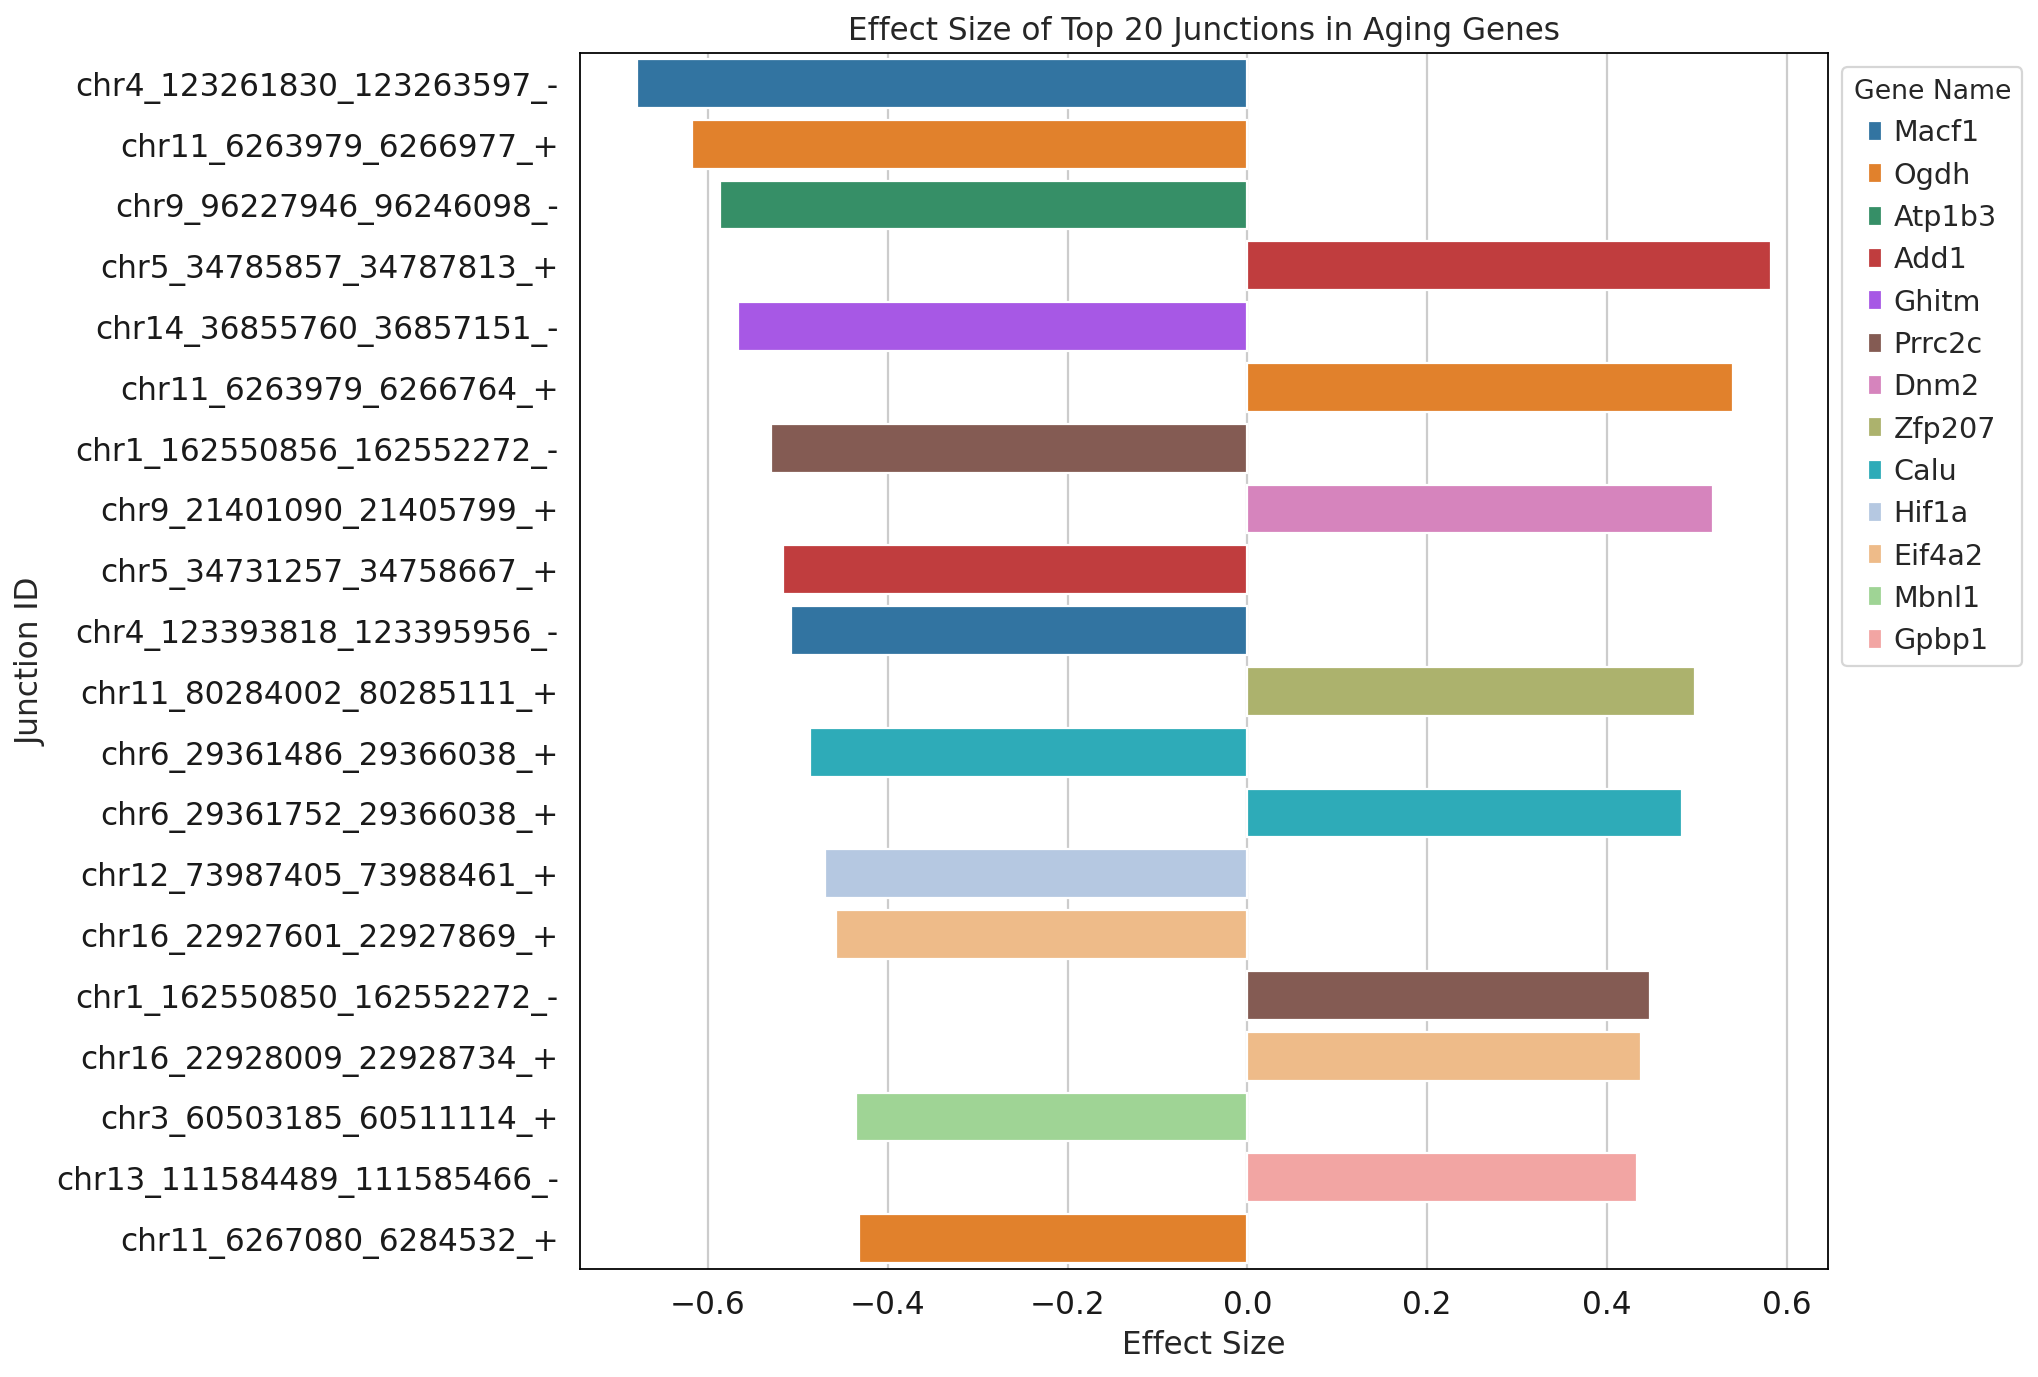

In [113]:
top_fact_juncs_df_SIG["junction_id_index"] = top_fact_juncs_df_SIG["junction_idx"].values 
# merge with adata.var 
top_fact_juncs_df_SIG = top_fact_juncs_df_SIG.merge(adata.var, on="junction_id_index")
# sort by SIG hits and decreasing abs effect size
top_fact_juncs_df_SIG = top_fact_juncs_df_SIG.sort_values(by=["significant", "abs_effect_size"], ascending=[False, False])
top_fact_juncs_df_SIG["log10FDR"] = -np.log(top_fact_juncs_df_SIG["fdr_curve"] + 1e-10)

# Let's take top 50 junctions and summarize their effect size in barplot and color by whether they are in known aging genes 
# keep just sig ones 
SIG_only = top_fact_juncs_df_SIG[top_fact_juncs_df_SIG["significant"]]
# now sort by abs effect size
SIG_only = SIG_only.sort_values(by="abs_effect_size", ascending=False)

print(SIG_only.global_aging_genes.value_counts())
aging_genes = SIG_only[SIG_only['global_aging_genes'] == True]

# Select the top 50 junctions with highest absolute effect size
top_50_junctions = aging_genes.nlargest(20, "abs_effect_size")

# convert gene_name to str 
top_50_junctions["gene_name"] = top_50_junctions["gene_name"].astype(str)

# Plot
plt.figure(figsize=(10, 10))
sns.barplot(x="effect_size", y="junction_id", data=top_50_junctions, hue="gene_name", dodge=False)

# Titles and labels
plt.title("Effect Size of Top 20 Junctions in Aging Genes")
plt.xlabel("Effect Size")
plt.ylabel("Junction ID")
plt.legend(title="Gene Name", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

In [117]:
SIG_only.sort_values(by="effect_size", ascending=False)

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,CountJuncs,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,transcripts,transcript_types,global_aging_genes,log10FDR
411,4,11234,0.625977,0.625977,0.002699,500.0,1.000,0.000,True,0.2,...,1230,924,0.093136,2.0,1.5,1,ENSMUST00000074575.11,protein_coding,False,23.025851
1477,4,13346,0.617676,0.617676,0.002520,500.0,1.000,0.000,True,0.2,...,676,573,0.057756,2.0,1.5,1,"ENSMUST00000115675.9,ENSMUST00000065932.14",protein_coding,False,23.025851
2901,4,10853,0.599121,0.599121,0.004852,500.0,1.000,0.000,True,0.2,...,419,379,0.038202,2.0,1.5,1,ENSMUST00000094053.7,protein_coding,False,23.025851
132,4,9836,0.582520,0.582520,0.005127,499.0,0.998,0.002,True,0.2,...,514,430,0.043342,2.0,1.5,1,ENSMUST00000114338.9,protein_coding,True,7.354906
1234,4,5275,0.580566,0.580566,0.006802,500.0,1.000,0.000,True,0.2,...,330,284,0.028626,2.0,1.5,1,ENSMUST00000237357.2,protein_coding,False,23.025851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,4,9223,-0.700195,0.700195,0.008751,500.0,1.000,0.000,True,0.2,...,276,242,0.024393,2.0,1.5,1,ENSMUST00000112519.9,protein_coding,False,23.025851
444,4,6036,-0.702148,0.702148,0.004135,500.0,1.000,0.000,True,0.2,...,1758,1261,0.127104,2.0,1.5,1,ENSMUST00000097453.9,protein_coding,False,23.025851
1203,4,2260,-0.738770,0.738770,0.012283,499.0,0.998,0.002,True,0.2,...,213,195,0.019655,2.0,1.5,1,ENSMUST00000055518.13,protein_coding,False,7.300075
9,4,4876,-0.744141,0.744141,0.001709,500.0,1.000,0.000,True,0.2,...,1702,1263,0.127306,2.0,1.5,1,ENSMUST00000072671.14,protein_coding,False,23.025851


/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = subset_cells.obs.groupby(group_column)[feature].median()
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:749: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset_cells.obs.groupby(group_column)[feature].mean()


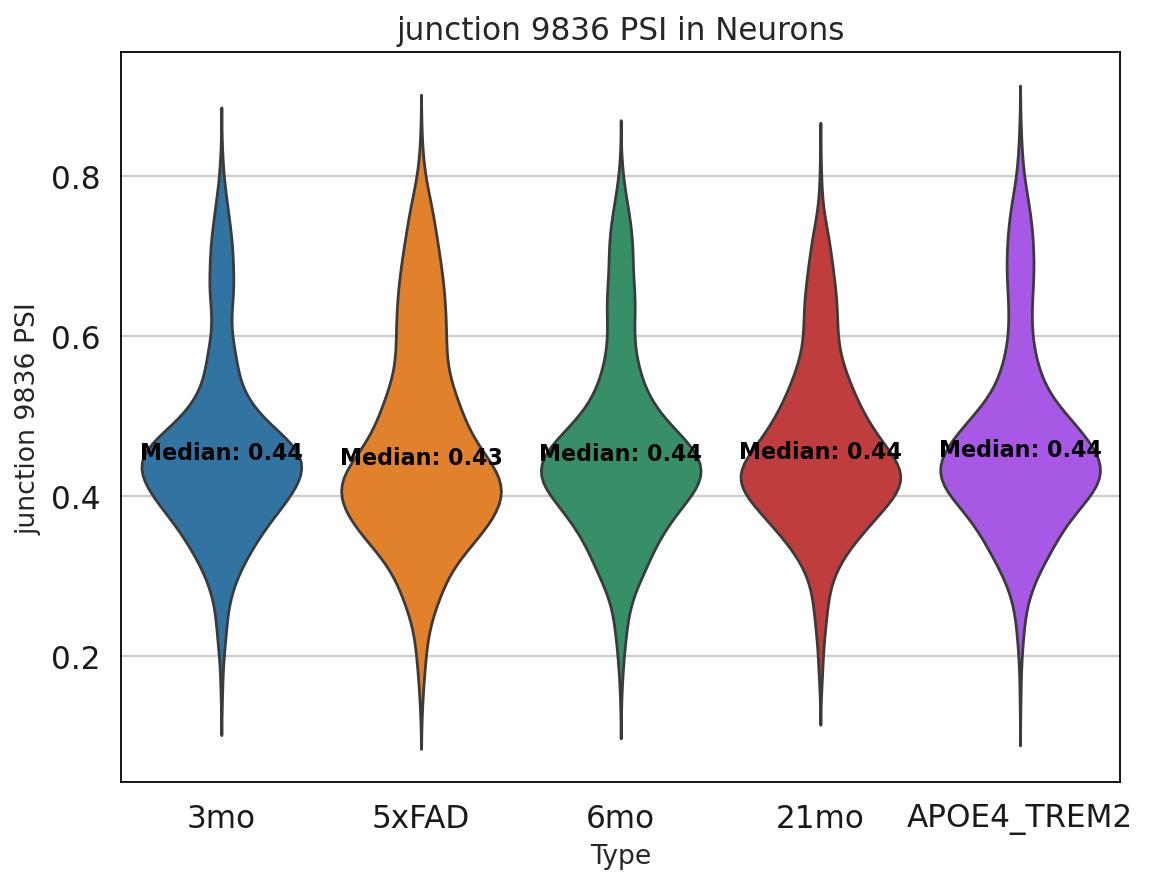

In [149]:
plot_violin_by_cell_type(adata, feature="junction", junction_idx=9836, cell_type_column="Cleaned_cluster_name", cell_type="Neurons", group_column="Type", size=(8,6))

In [128]:
SIG_only.sort_values(by="effect_size", ascending=False).iloc[1]

factor_idx                                                           4
junction_idx                                                     13346
effect_size                                                   0.617676
abs_effect_size                                               0.617676
effect_size_var                                                0.00252
num_greater                                                      500.0
prob_greater                                                       1.0
prob_lessoreq                                                      0.0
significant                                                       True
delta                                                              0.2
psi_factor_mean                                               0.927734
psi_nonfactor_mean                                            0.310303
fdr_curve                                                          0.0
n_significant                                                     1282
juncti

/scratch/ipykernel_2386617/3540060010.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  juncs["usage_ratio"] = juncs["total_score"]
/scratch/ipykernel_2386617/3540060010.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  juncs["Cluster"] = juncs["event_id"]
100%|██████████| 3/3 [00:00<00:00,  5.41it/s]


Plot saved to test!


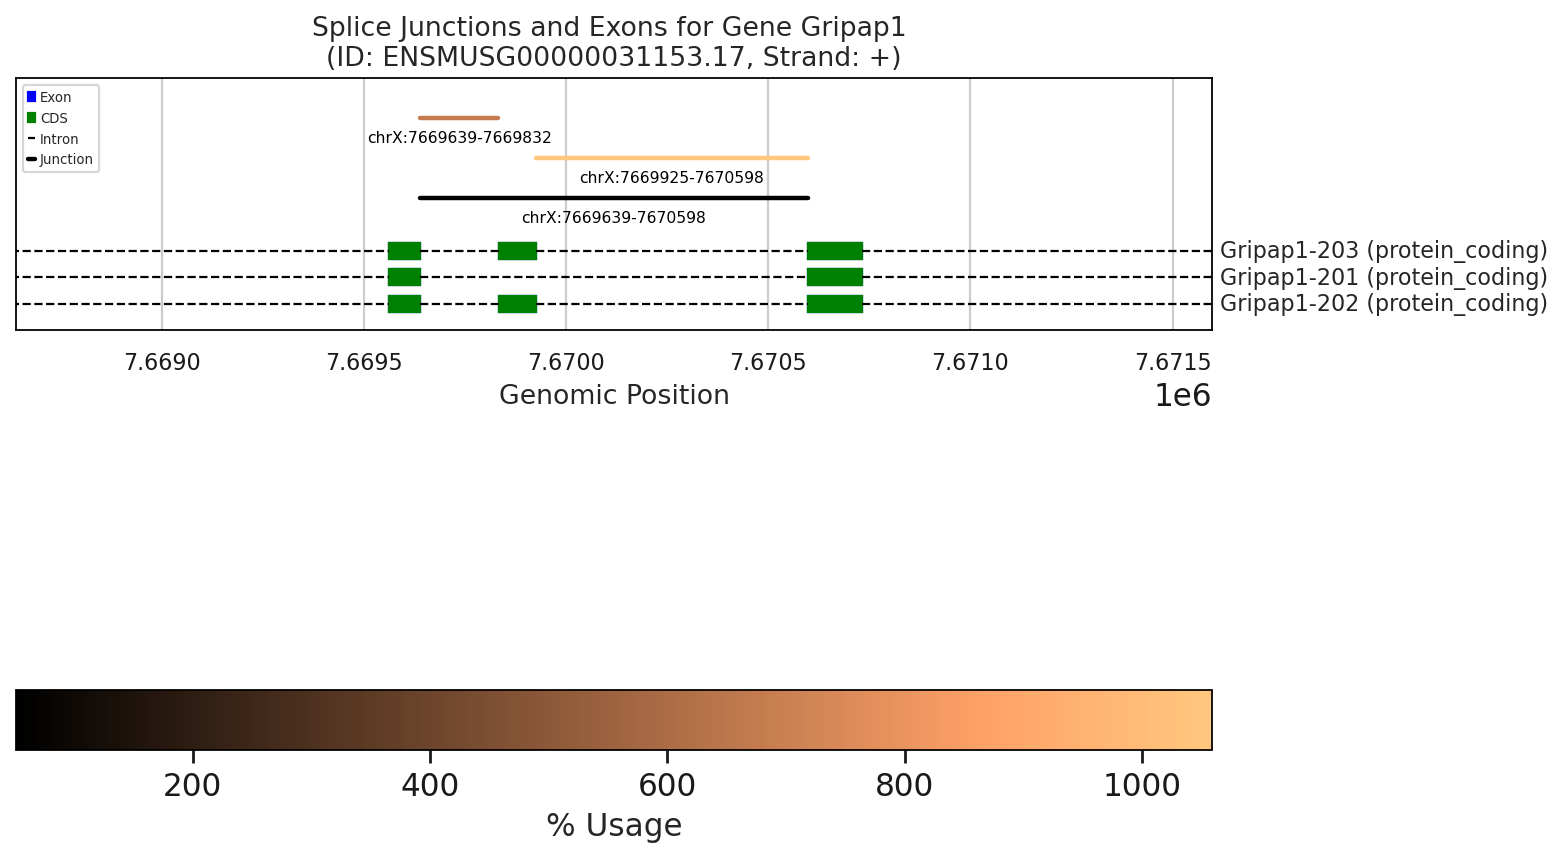

In [129]:
atse_event = "ATSE_2858"
juncs = atses[atses["event_id"]==atse_event]
juncs["usage_ratio"] = juncs["total_score"]
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start, region_end, base_width=10, trans_height=1.5, show_usage=True, show_junc_lines=False, filename="test")



In [144]:
adata.var[adata.var["junction_id"].isin(juncs.junction_id.values)][["junction_id", "junction_id_index"]]

,junction_id,junction_id_index
13346,chrX_7669639_7669832_+,13346
13347,chrX_7669639_7670598_+,13347
13348,chrX_7669925_7670598_+,13348


/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = subset_cells.obs.groupby(group_column)[feature].median()
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:749: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset_cells.obs.groupby(group_column)[feature].mean()


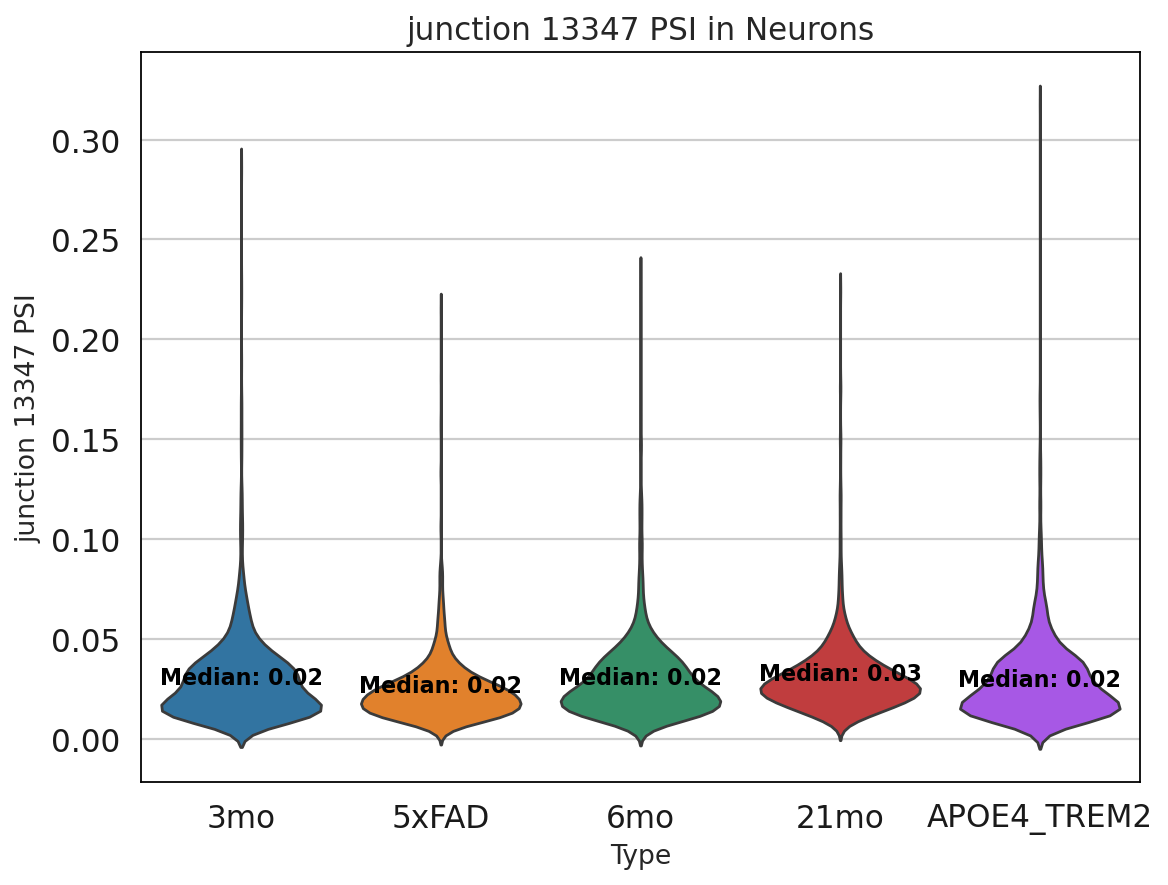

In [140]:
plot_violin_by_cell_type(adata, feature="junction", junction_idx=13347, cell_type_column="Cleaned_cluster_name", cell_type="Neurons", group_column="Type", size=(8,6))

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = subset_cells.obs.groupby(group_column)[feature].median()
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:749: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset_cells.obs.groupby(group_column)[feature].mean()


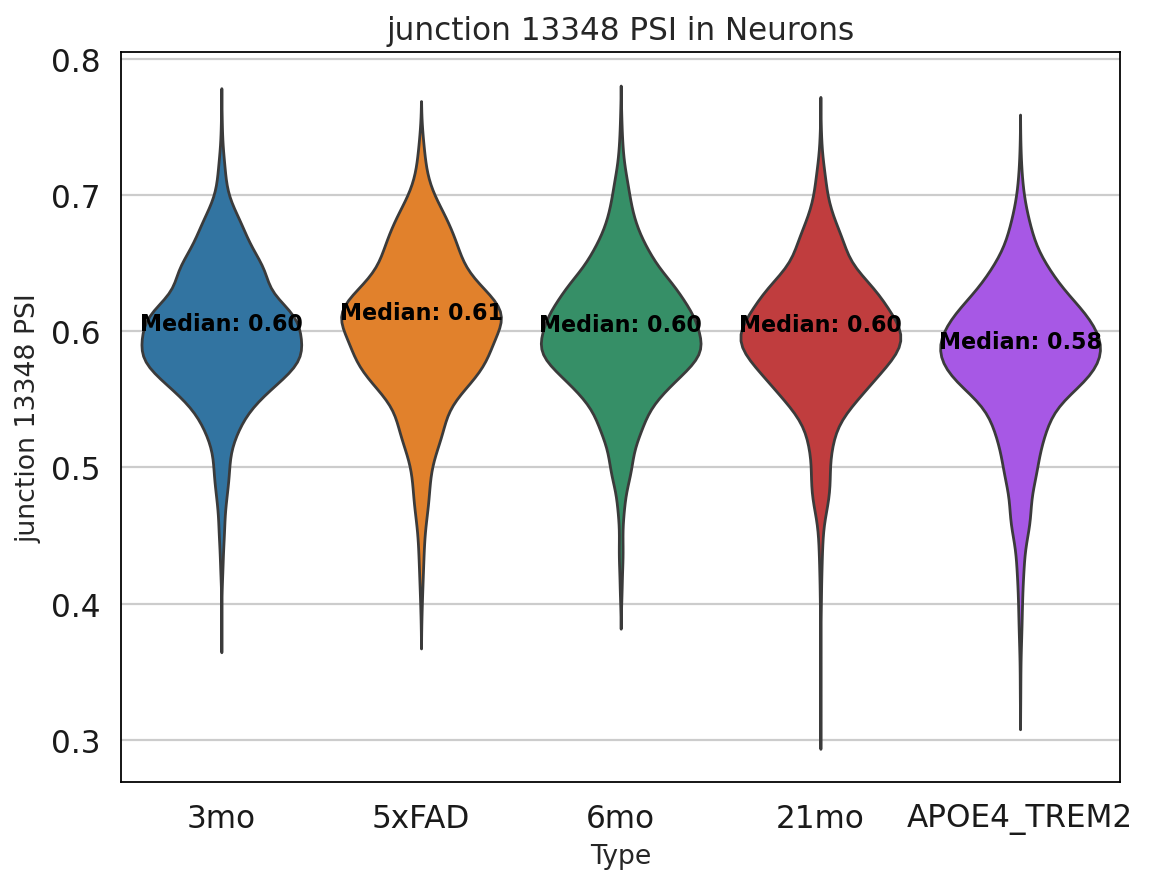

In [141]:
plot_violin_by_cell_type(adata, feature="junction", junction_idx=13348, cell_type_column="Cleaned_cluster_name", cell_type="Neurons", group_column="Type", size=(8,6))

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = subset_cells.obs.groupby(group_column)[feature].median()
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:749: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset_cells.obs.groupby(group_column)[feature].mean()


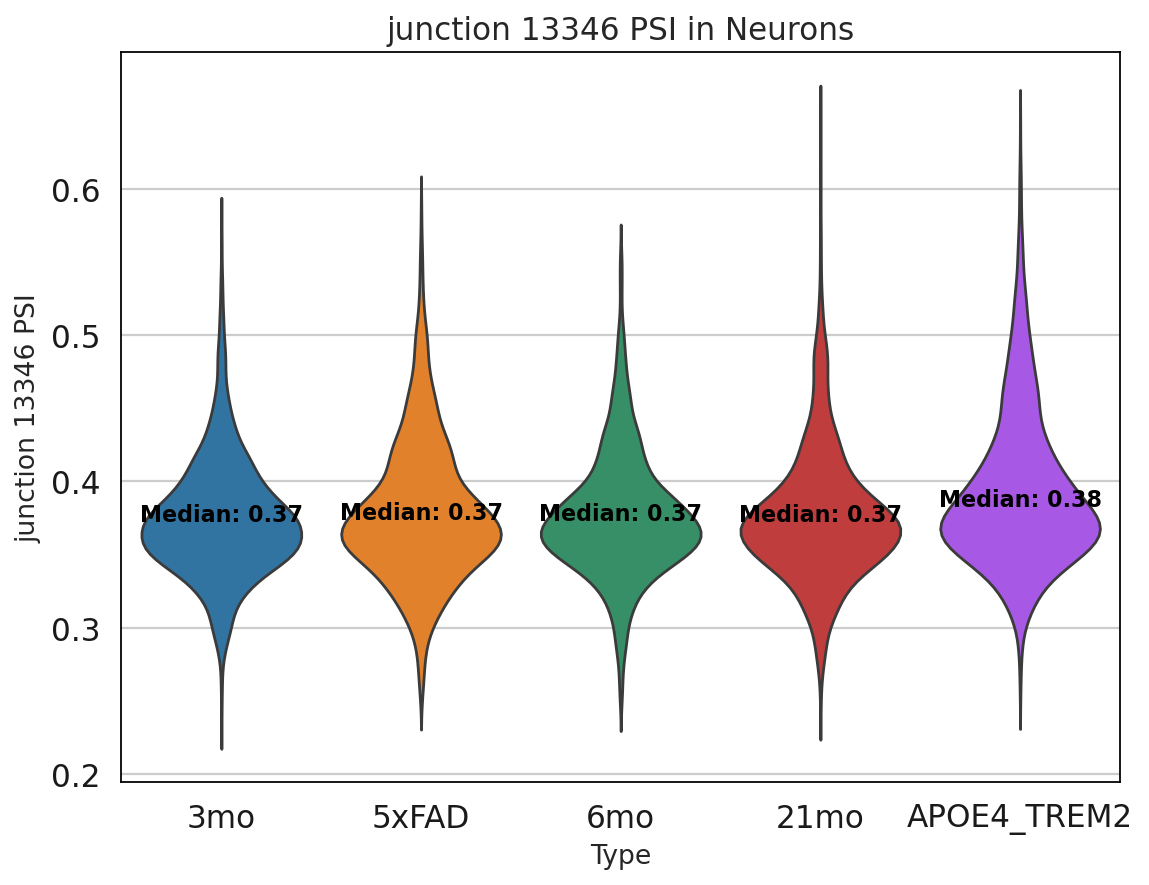

In [133]:
plot_violin_by_cell_type(adata, feature="junction", junction_idx=13346, cell_type_column="Cleaned_cluster_name", cell_type="Neurons", group_column="Type", size=(8,6))

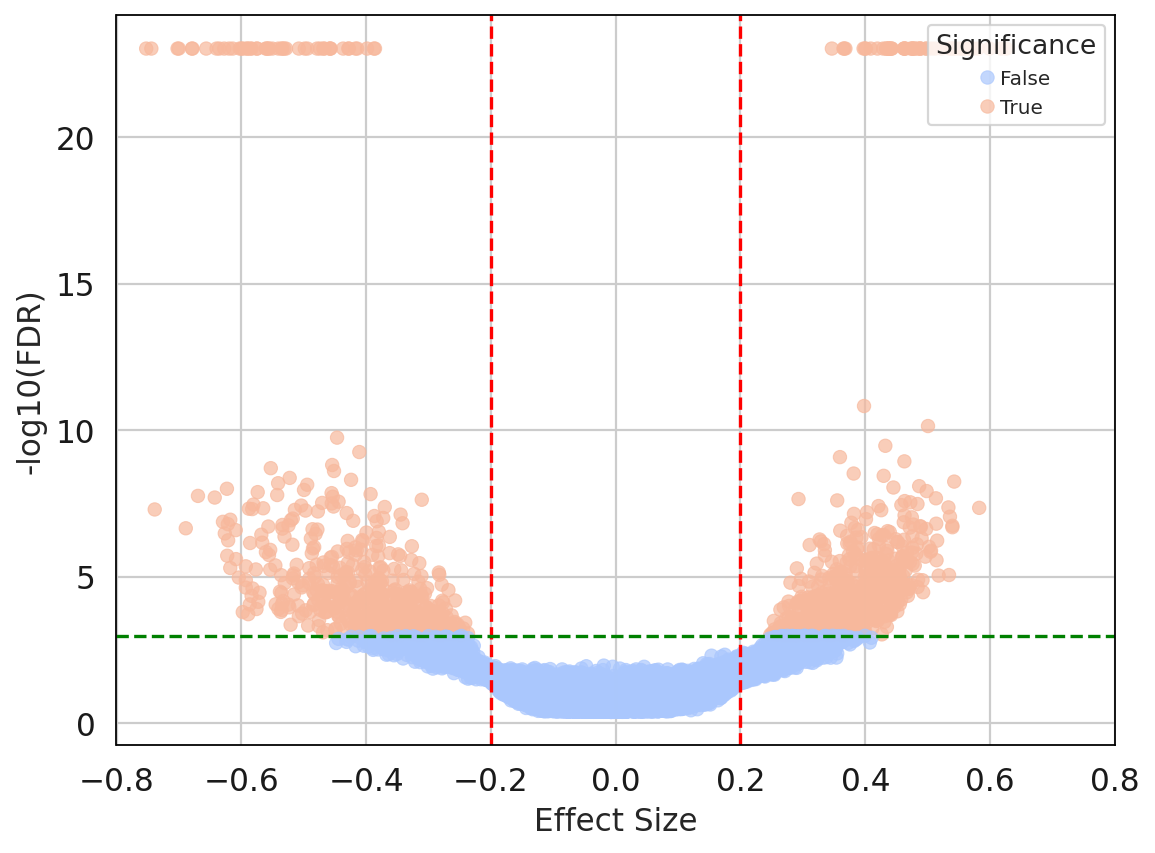

In [147]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="effect_size", y="log10FDR", data=top_fact_juncs_df_SIG, 
                hue="significant", palette="coolwarm", alpha=0.7, edgecolor=None)
# add vertical line at 0.2 effect size
plt.axvline(0.2, color="red", linestyle="--")
plt.axvline(-0.2, color="red", linestyle="--")
# add horizontal line at 0.05 FDR
plt.axhline(-np.log(0.05), color="green", linestyle="--")
# xlim -0.8 to 0.8
plt.xlim(-0.8, 0.8)
# Axis labels
plt.xlabel("Effect Size")
plt.ylabel("-log10(FDR)")
# Improve the legend
plt.legend(title="Significance", loc="upper right", fontsize=9)

In [148]:
# subset top_fact_juncs_df_SIG by log10FDR values greater than 20
top_fact_juncs_df_SIG[top_fact_juncs_df_SIG["log10FDR"] > 20].annotation_status.value_counts()

annotation_status
both           93
five_prime      5
three_prime     2
unannotated     0
Name: count, dtype: int64

In [ ]:
results = ds.analyze_all_factors_psi(psi_samples, top_junctions, min_effect_size=0.25)

In [ ]:
all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    
    # Append to list
    all_results.append(significance_df)

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]

In [ ]:
# Merge with adata.var using junction_id_index
final_df = final_df.merge(adata.var, on="junction_id_index")
# filter just significant junctions
final_df = final_df[final_df["significant"]]
# calculate perplexity based on number of factors a junction is significant in
perplexity = final_df.groupby("junction_id_index")["factor_idx"].nunique()
final_df["perplexity"] = final_df["junction_id_index"].map(perplexity)
# sort by perplexity
final_df.sort_values(by="perplexity", ascending=False)

In [ ]:
final_df.factor_idx.value_counts()

In [ ]:
adata.var[adata.var["event_id"] == "ATSE_20168"].junction_id_index.values, adata.var[adata.var["event_id"] == "ATSE_20168"].junction_id.values

In [ ]:
adata.var[adata.var["junction_id_index"] == 30505].junction_id

In [ ]:
adata.var[adata.var["junction_id_index"] == 30516].junction_id

In [ ]:
importlib.reload(ds)

In [ ]:
ds.plot_psi_distribution(psi_samples, junction_idx=30516, ref_factor=10)  

In [ ]:
# Example usage:
ds.plot_psi_distribution(psi_samples, junction_idx=30505, ref_factor=10)  

In [ ]:
juncs = atses[atses["event_id"]=="ATSE_20168"]
juncs["usage_ratio"] = juncs["total_score"]
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start, region_end, base_width=15, trans_height=2, show_usage=True, show_junc_lines=False)



In [ ]:
# Calculate entropy for each cell, ensuring numerical stability (avoid log(0))
PHI_safe = np.clip(PHI, 1e-10, 1)  # Prevent log(0) errors
entropy = -np.sum(PHI_safe * np.log(PHI_safe), axis=1)

# Calculate perplexity for each cell
perplexity = np.exp(entropy)

# Store results in `adata.obs`
adata.obs["perplexity"] = perplexity
adata.obs["entropy"] = entropy

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=adata.obs, x="perplexity", hue="age", bins=30, kde=True, element="step")

# Get median perplexity per age group
median_perplexity = adata.obs.groupby("age")["perplexity"].median()

# Assign distinct colors from the KDE curves to the median lines
palette = sns.color_palette("tab10", n_colors=len(median_perplexity))  # Use same color set as Seaborn
color_dict = dict(zip(median_perplexity.index, palette))  # Map age group to color

# Add median lines with matching colors
for age_group, median in median_perplexity.items():
    plt.axvline(median, color=color_dict[age_group], linestyle="--", linewidth=1.5, label=f"Median ({age_group})")

# Set x-axis ticks to 0, 2, 4, ...
plt.xticks(np.arange(0, max(perplexity) + 2, 2))

# Labels and title
plt.xlabel("Perplexity (Number of Factors Active)", fontsize=15)
plt.ylabel("Number of Cells", fontsize=15)

# Increase font size of xaxis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Ensure legend appears
plt.legend()

# Display the plot
plt.show()

In [ ]:
cell_type_1 = "GLIAL CELL"
cell_type_2 = None
all_ds_neuron = []

# Iterate over each junction index and compute differential splicing
for junction_id_index in tqdm(top_junctions, desc="Computing differential splicing"):
    try:
        ds_results = ds.compute_differential_splicing_groups(
            adata, psi_samples, phi_samples, junction_id_index, group_1=cell_type_1, group_2=cell_type_2, 
            groupby_column="cell_type_grouped", min_effect_size=0.1
        )
        all_ds_neuron.append(ds_results)
    except Exception as e:
        print(f"Error processing junction {junction_id_index}: {e}")

# Convert results into a DataFrame
df_all_ds_neuron = pd.DataFrame(all_ds_neuron)
df_all_ds_neuron_sig = ds.compute_junctions_significance_groups(df_all_ds_neuron, min_effect_size=0.1)
df_all_ds_neuron_sig["junction_id_index"] = df_all_ds_neuron_sig["junction_idx"]
# merge with adata.var using junction_id_index
df_all_ds_neuron_sig = df_all_ds_neuron_sig.merge(adata.var, on="junction_id_index")

In [ ]:
leaflet_model.bb_conc

In [ ]:
df_all_ds_neuron_sig.sort_values(by=["significant", "effect_size"], ascending=[False, False]).head()

In [ ]:
# Let's compare young versus the rest 
group1 = "3m"
group2 = "24m" 
young_vs_old = []
min_effect_size = 0.1

# Iterate over each junction index and compute differential splicing
for junction_id_index in tqdm(top_junctions, desc="Computing differential splicing"):
    try:
        ds_results = ds.compute_differential_splicing_groups(
            adata, psi_samples, phi_samples, junction_id_index, group_1=group1, group_2=group2, 
            groupby_column="age", min_effect_size=min_effect_size
        )
        young_vs_old.append(ds_results)
    except Exception as e:
        print(f"Error processing junction {junction_id_index}: {e}")

# Convert results into a DataFrame
df_young_vs_old = pd.DataFrame(young_vs_old)
df_young_vs_old_sig = ds.compute_junctions_significance_groups(df_young_vs_old, min_effect_size=min_effect_size)
df_young_vs_old_sig["junction_id_index"] = df_young_vs_old_sig["junction_idx"]
# merge with adata.var using junction_id_index
df_young_vs_old_sig = df_young_vs_old_sig.merge(adata.var, on="junction_id_index")

In [ ]:
adata.obs.age.value_counts()

In [ ]:
# use adata.layers["PSI_CELLS"] for junction 24461 to plot on top of umap 
junction_id_index = 24066
adata.obs["junction_activity"] = adata.layers["PSI_CELLS"][:, junction_id_index]

# visualize junction 24461 and factor 18 usage across cells side by side
sc.pl.umap(adata, color=["cell_type_grouped", "junction_activity"], wspace=0.9, size=8, ncols=1)

In [ ]:
atse_event = "ATSE_12365"
juncs = atses[atses["event_id"]==atse_event]
juncs["usage_ratio"] = juncs["total_score"]
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start, region_end, base_width=10, trans_height=1.5, show_usage=True, show_junc_lines=False, filename="test")



### How do expression PCs correlate with factor PCs?

In [ ]:
# subset gene expression to microglial cells
microglia_ge = ge_adata[ge_adata.obs["cell_type_grouped"] == "MICROGLIA"]
microglia_splicing = adata[adata.obs["cell_type_grouped"] == "MICROGLIA"]

In [ ]:
# first ensrue that microglia_ge and microglia_splicing have the same order of cells
assert np.all(microglia_ge.obs.index == microglia_splicing.obs.index)

In [ ]:
# Get the gene expression matrix PCs
X_microglia_ge = microglia_ge.obsm["X_pca"][:, :30]  # (n_cells, 10)
X_microglia_splicing = microglia_splicing.obsm["X_PHI"]  # (n_cells, n_factors)

# Compute correlation matrix (10 PCs by n_factors) and transpose to put PCs on x-axis
correlation_matrix = np.corrcoef(X_microglia_ge.T, X_microglia_splicing.T)[:30, 30:].T  # Shape is now (n_factors, 10)

# Define labels
factor_labels = [f"Factor {i}" for i in range(X_microglia_splicing.shape[1])]
pc_labels = [f"PC {i}" for i in range(30)]

# Create clustermap with adjusted orientation
g = sns.clustermap(correlation_matrix, cmap="coolwarm", center=0, annot=False,
                   xticklabels=pc_labels, yticklabels=factor_labels, figsize=(10, 8))

# Adjust label rotation and position
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)  # PCs now horizontal
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)  # Factors readable

# Highlight "Factor 10" in red
for label in g.ax_heatmap.get_yticklabels():
    if label.get_text() == "Factor 10":
        label.set_color("red")

# Set axis labels and title
g.ax_heatmap.set_xlabel("Gene Expression PCs")
g.ax_heatmap.set_ylabel("Splicing Factors")
#g.ax_heatmap.set_title("Correlation Matrix of Gene Expression PCs and \nSplicing Factors in Microglia")

plt.show()


In [ ]:
# Get the gene expression matrix PCs
X_ge = ge_adata.obsm["X_pca"][:, :30]  # (n_cells, 10)
X_splicing = adata.obsm["X_PHI"]  # (n_cells, n_factors)

# Compute correlation matrix (10 PCs by n_factors) and transpose to put PCs on x-axis
correlation_matrix = np.corrcoef(X_ge.T, X_splicing.T)[:30, 30:].T  # Shape is now (n_factors, 10)

# Define labels
factor_labels = [f"Factor {i}" for i in range(X_splicing.shape[1])]
pc_labels = [f"PC {i}" for i in range(30)]

# Create clustermap with adjusted orientation
g = sns.clustermap(correlation_matrix, cmap="coolwarm", center=0, annot=False,
                   xticklabels=pc_labels, yticklabels=factor_labels, figsize=(10, 8))

# Adjust label rotation and position
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)  # PCs now horizontal
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)  # Factors readable

# Highlight "Factor 10" in red
for label in g.ax_heatmap.get_yticklabels():
    if label.get_text() == "Factor 10":
        label.set_color("red")

# Set axis labels and title
g.ax_heatmap.set_xlabel("Gene Expression PCs")
g.ax_heatmap.set_ylabel("Splicing Factors")
g.ax_heatmap.set_title("Correlation Matrix of Gene Expression PCs and \nSplicing Factors in ALL cells")

plt.show()


In [ ]:
np.median(ge_adata[:, "Csde1"].X.toarray())

In [ ]:
ge_adata[:, "Csde1"].X.toarray().mean()

In [ ]:
ge_adata.var_names

In [ ]:
# get Csde1 expression in microglia as violin plot by age group
plot_violin_by_cell_type(ge_adata, feature="gene", gene_name="Csde1", cell_type_column="cell_type_grouped", cell_type=None, group_column="age", size=(6,6))

In [ ]:
# Set parameters
num_cells = 5  # Number of cells
num_junctions = 3  # Number of junctions per cell
read_depth = 100  # Fixed total read depth per junction

# Define different concentration values (alpha + beta)
concentration_values = [3.5, 100, 1000]

# Initialize figure
fig, axes = plt.subplots(len(concentration_values), num_junctions, figsize=(12, 8), sharex=True, sharey=True)

# Simulate and plot distributions
for i, concentration in enumerate(concentration_values):
    alpha_beta = concentration / 2  # Split evenly (symmetric Beta prior)
    
    for j in range(num_junctions):
        # Sample mean success probability from Beta prior
        mu = np.random.beta(alpha_beta, alpha_beta, size=num_cells)  # One per cell
        
        # Sample junction reads from Beta-Binomial
        counts = [stats.betabinom.rvs(read_depth, alpha_beta, alpha_beta, size=1)[0] for _ in range(num_cells)]
        
        # Plot histogram
        ax = axes[i, j] if num_junctions > 1 else axes[i]
        ax.hist(counts, bins=np.arange(0, read_depth + 5, 5), alpha=0.7, color='blue', edgecolor='black')
        ax.set_title(f"Junction {j+1}, Concentration={concentration}")
        ax.set_xlabel("Spliced Reads")
        ax.set_ylabel("Frequency")
        
# Adjust layout and show
plt.tight_layout()
plt.show()
